In [27]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("/Users/ekaterinaleontieva/test/wintermute_transfers_search_default_2025-04-08.csv")

print(df)



                        timestamp  \
0       2025-04-08 12:49:57+00:00   
1       2025-04-08 12:49:54+00:00   
2       2025-04-08 12:49:51+00:00   
3       2025-04-08 12:49:51+00:00   
4       2025-04-08 12:49:50+00:00   
...                           ...   
436995  2025-04-08 01:30:11+00:00   
436996  2025-04-08 01:30:11+00:00   
436997  2025-04-08 01:30:11+00:00   
436998  2025-04-08 01:30:11+00:00   
436999  2025-04-08 01:30:11+00:00   

                                        from_address  \
0         0xB1026b8e7276e7AC75410F1fcbbe21796e8f7526   
1         0xcDa53B1F66614552F834cEeF361A8D12a0B8DaD8   
2         0xb2cc224c1c9feE385f8ad6a55b4d94E92359DC59   
3         0x51C72848c68a965f66FA7a88855F9f7784502a7F   
4         0x641C00A822e8b671738d32a431a4Fb6074E5c79d   
...                                              ...   
436995    0x51C72848c68a965f66FA7a88855F9f7784502a7F   
436996    0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640   
436997    0xEae7380dD4CeF6fbD1144F49E4D1e6964258A4F

In [28]:
import pandas as pd


df_raw = df = pd.read_csv("/Users/ekaterinaleontieva/test/wintermute_transfers_search_default_2025-04-08.csv")


df = df_raw.copy()


df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")


df = df[df["timestamp"].notna()]         
df = df[df["usd"].notna()]         
df = df[df["usd"] > 0]              
df = df[df["token"].notna()]             
df = df[df["chain"].notna()]        


df = df.drop_duplicates(
    subset=["tx_hash", "from_address", "to_address", "token", "value", "usd"]
)

print("Raw shape:", df_raw.shape)
print("Clean shape:", df.shape)


Raw shape: (437000, 11)
Clean shape: (429558, 11)


In [29]:
df.isna().mean().sort_values(ascending=False)


from_entity     0.076085
to_entity       0.068405
timestamp       0.000000
from_address    0.000000
to_address      0.000000
token           0.000000
value           0.000000
usd             0.000000
tx_hash         0.000000
chain           0.000000
block_number    0.000000
dtype: float64

Entity Classification:

In [30]:
entities= pd.unique(df[['from_entity','to_entity']].values.ravel('K'))
entities

array(['Camelot', 'Uniswap', 'Aerodrome Finance', 'Wintermute',
       'PancakeSwap', 'Fluid (Instadapp)', 'CoW Protocol', nan, 'Raydium',
       'Orca', 'Meteora (Prev. Mercurial)', 'Phoenix', 'Binance',
       'MetaMask', 'ParaSwap', 'Curve.fi', 'OKX', '0x', 'Coinbase',
       'Bybit', 'LiFi', 'SushiSwap', 'Rizzolver (Wintermute)', 'Bebop',
       'Crypto.com', 'Lifinity', 'Bullish.com', 'Bitstamp', 'Rainbow.me',
       '@glatebois', 'Gate.io', 'Backpack Exchange', 'Unizen', 'Bitvavo',
       'ShibaSwap', 'Paxos', 'Kraken', '1inch',
       'The T Resolver (1inch Resolver)', '@eiiriknft', '@larutadeclau',
       '@bitcocks', 'Velodrome Finance', '@MatDefies', 'Ethena',
       '@MrBigTimeCEO', '@averagecontract', '@shift_cipher',
       '@quantumEVM18', '@TheCheckedBid33', '@CryptoChamp87',
       '@CipherCraze55', '@NebulaVista99', '@SolsticeVault',
       '@SolanaSeeker', '@BinarySaga_', '@CipherNebulae', '@ec1ipse_sol',
       'KuCoin', '@TrueNFT33', '@inicola86', 'Bitfinex', '@Anon

In [31]:
entities = [e for e in entities if pd.notna(e)]
entities

['Camelot',
 'Uniswap',
 'Aerodrome Finance',
 'Wintermute',
 'PancakeSwap',
 'Fluid (Instadapp)',
 'CoW Protocol',
 'Raydium',
 'Orca',
 'Meteora (Prev. Mercurial)',
 'Phoenix',
 'Binance',
 'MetaMask',
 'ParaSwap',
 'Curve.fi',
 'OKX',
 '0x',
 'Coinbase',
 'Bybit',
 'LiFi',
 'SushiSwap',
 'Rizzolver (Wintermute)',
 'Bebop',
 'Crypto.com',
 'Lifinity',
 'Bullish.com',
 'Bitstamp',
 'Rainbow.me',
 '@glatebois',
 'Gate.io',
 'Backpack Exchange',
 'Unizen',
 'Bitvavo',
 'ShibaSwap',
 'Paxos',
 'Kraken',
 '1inch',
 'The T Resolver (1inch Resolver)',
 '@eiiriknft',
 '@larutadeclau',
 '@bitcocks',
 'Velodrome Finance',
 '@MatDefies',
 'Ethena',
 '@MrBigTimeCEO',
 '@averagecontract',
 '@shift_cipher',
 '@quantumEVM18',
 '@TheCheckedBid33',
 '@CryptoChamp87',
 '@CipherCraze55',
 '@NebulaVista99',
 '@SolsticeVault',
 '@SolanaSeeker',
 '@BinarySaga_',
 '@CipherNebulae',
 '@ec1ipse_sol',
 'KuCoin',
 '@TrueNFT33',
 '@inicola86',
 'Bitfinex',
 '@AnonPartTime',
 'Arctic Bastion (1inch Resolver)',
 

In [32]:
entities_df = pd.DataFrame({
    'entity': entities
})

entities_df.head()


,entity
0,Camelot
1,Uniswap
2,Aerodrome Finance
3,Wintermute
4,PancakeSwap


In [33]:
entities_overview = entities_df.copy()
entities_overview["source"] = "Heuristic / public labels"  
entities_overview.head(20)


,entity,source
0,Camelot,Heuristic / public labels
1,Uniswap,Heuristic / public labels
2,Aerodrome Finance,Heuristic / public labels
3,Wintermute,Heuristic / public labels
4,PancakeSwap,Heuristic / public labels
5,Fluid (Instadapp),Heuristic / public labels
6,CoW Protocol,Heuristic / public labels
7,Raydium,Heuristic / public labels
8,Orca,Heuristic / public labels
9,Meteora (Prev. Mercurial),Heuristic / public labels


In [34]:

entities = pd.unique(df[['from_entity', 'to_entity']].values.ravel())
entities = [e for e in entities if pd.notna(e)]
entities_df = pd.DataFrame({"entity": entities})
defi_list = [
    'Camelot','Uniswap','Aerodrome Finance','PancakeSwap','Fluid (Instadapp)',
    'CoW Protocol','Raydium','Orca','Meteora (Prev. Mercurial)','Phoenix',
    'ParaSwap','Curve.fi','0x','LiFi','SushiSwap','Lifinity','ShibaSwap',
    'Velodrome Finance','Sky (MakerDAO)','1inch',
    'The T Resolver (1inch Resolver)','Arctic Bastion (1inch Resolver)',
    'Kyber Network','Odos','Bebop','Jito'
]

cefi_list = [
    'Binance','OKX','Coinbase','Bybit','Crypto.com','Bullish.com','Bitstamp',
    'Gate.io','Backpack Exchange','Unizen','Bitvavo','Coinhako','Bitfinex',
    'BitMart','Paxos','Circle','Kraken','KuCoin'
]

wallet_list   = ['MetaMask','Rainbow.me','Zerion']
internal_list = ['Wintermute','Rizzolver (Wintermute)']
infra_list    = ['rsync-builder'] 

def classify_entity(e: str) -> str:
    if e in defi_list:
        return "DeFi"
    if e in cefi_list:
        return "Non-DeFi (CEX)"
    if e in wallet_list:
        return "Non-DeFi (Wallet)"
    if e in internal_list:
        return "Non-DeFi (Internal)"
    if e in infra_list:
        return "Non-DeFi (Infra)"

    e_lower = e.lower()
    if any(kw in e_lower for kw in ["swap", "dex", "amm", "dao", "protocol", "finance"]):
        return "DeFi"
    if any(kw in e_lower for kw in ["exchange", "binance", "kraken", "coinbase",
                                    "okx", "bybit", "kucoin", "bitfinex", "bitstamp"]):
        return "Non-DeFi (CEX)"
    if any(kw in e_lower for kw in ["mask", "rainbow", "zerion", "wallet"]):
        return "Non-DeFi (Wallet)"
    if e.startswith("@"):
        return "Non-DeFi (Unknown individual)"
    if "wintermute" in e_lower:
        return "Non-DeFi (Internal)"
    return "Non-DeFi (Unknown)" 
entities_df["classification"] = entities_df["entity"].apply(classify_entity)
entities_df


,entity,classification
0,Camelot,DeFi
1,Wintermute,Non-DeFi (Internal)
2,Uniswap,DeFi
3,Aerodrome Finance,DeFi
4,PancakeSwap,DeFi
...,...,...
79,@Xaoxin_Ka,Non-DeFi (Unknown individual)
80,Kyber Network,DeFi
81,@tonydanv,Non-DeFi (Unknown individual)
82,@itzTenzy_,Non-DeFi (Unknown individual)


In [35]:
entities_df["classification"].value_counts()


classification
Non-DeFi (Unknown individual)    33
DeFi                             26
Non-DeFi (CEX)                   17
Non-DeFi (Wallet)                 3
Non-DeFi (Internal)               2
Non-DeFi (Unknown)                2
Non-DeFi (Infra)                  1
Name: count, dtype: int64

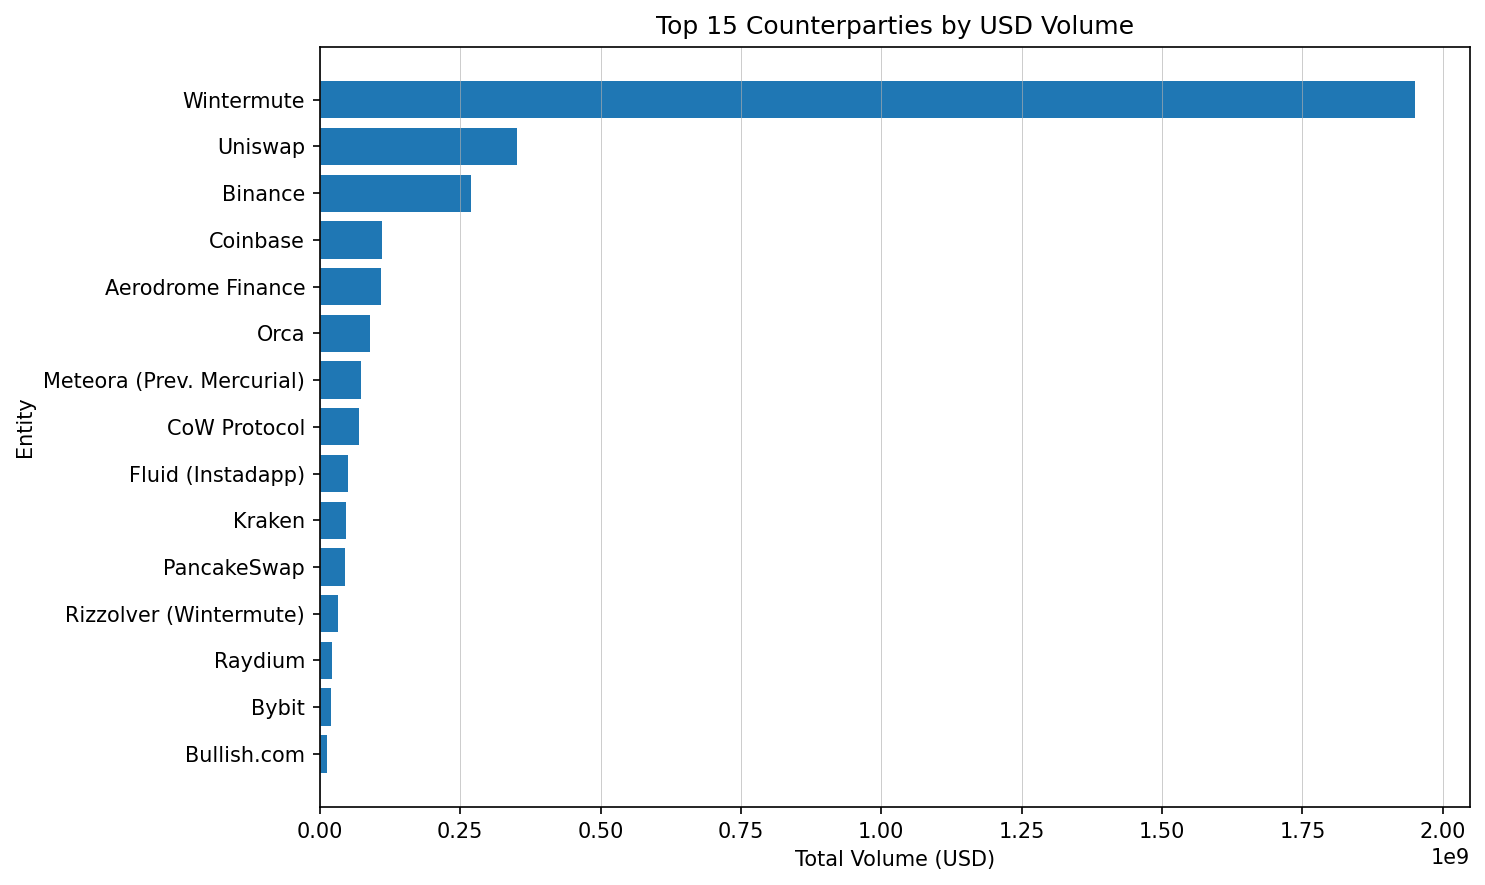

In [36]:

vol_from = df.groupby("from_entity")["usd"].sum()
vol_to   = df.groupby("to_entity")["usd"].sum()

total_vol = vol_from.add(vol_to, fill_value=0)
total_vol = total_vol.dropna()

entity_vol = (
    total_vol.rename("total_usd")
    .to_frame()
    .reset_index()
    .rename(columns={"index": "entity"})
)

entity_vol = entity_vol.merge(entities_df, on="entity", how="left")


top15 = entity_vol.sort_values("total_usd", ascending=False).head(15)

plt.figure(figsize=(10,6), dpi=150)
plt.barh(top15["entity"], top15["total_usd"])

plt.title("Top 15 Counterparties by USD Volume")
plt.xlabel("Total Volume (USD)")
plt.ylabel("Entity")
plt.gca().invert_yaxis()  #
plt.grid(axis="x", linewidth=0.3)
plt.tight_layout()
plt.show()


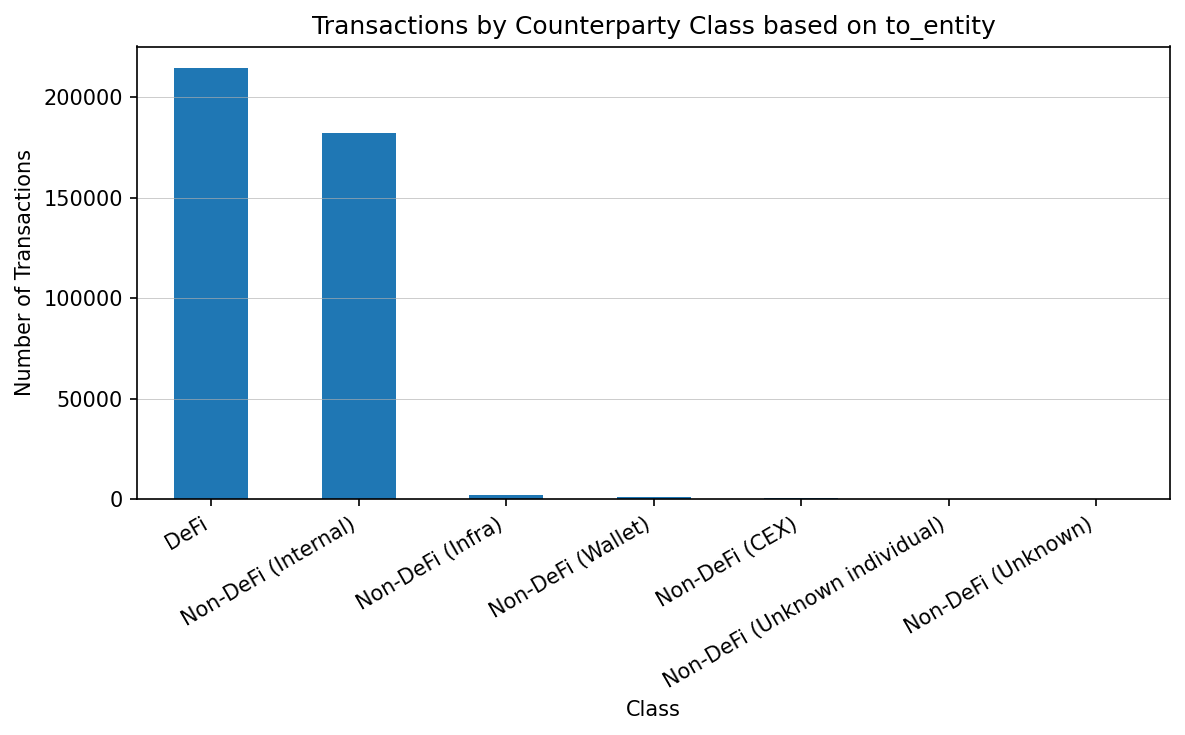

In [37]:

class_map = dict(zip(entities_df["entity"], entities_df["classification"]))
df["to_class"]  = df["to_entity"].map(class_map)
df["from_class"] = df["from_entity"].map(class_map)
tx_counts = df["to_class"].value_counts()
plt.figure(figsize=(8,5), dpi=150)
tx_counts.plot(kind="bar")

plt.title("Transactions by Counterparty Class based on to_entity")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linewidth=0.3)
plt.tight_layout()
plt.show()



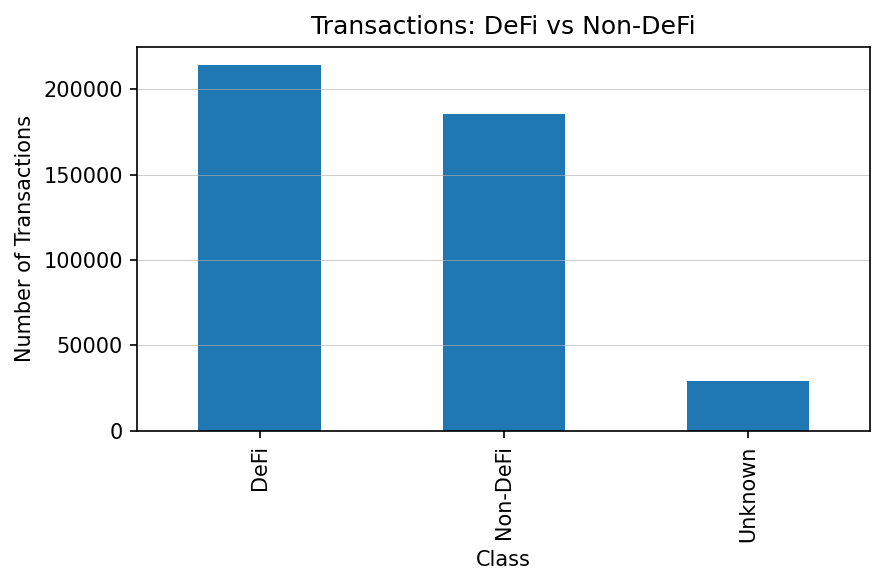

In [38]:
def coarse_class(c):
    if c == "DeFi":
        return "DeFi"
    elif pd.isna(c):
        return "Unknown"
    else:
        return "Non-DeFi"

df["to_class_coarse"] = df["to_class"].apply(coarse_class)
coarse_counts = df["to_class_coarse"].value_counts()

plt.figure(figsize=(6,4), dpi=150)
coarse_counts.plot(kind="bar")

plt.title("Transactions: DeFi vs Non-DeFi")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", linewidth=0.3)
plt.tight_layout()
plt.show()


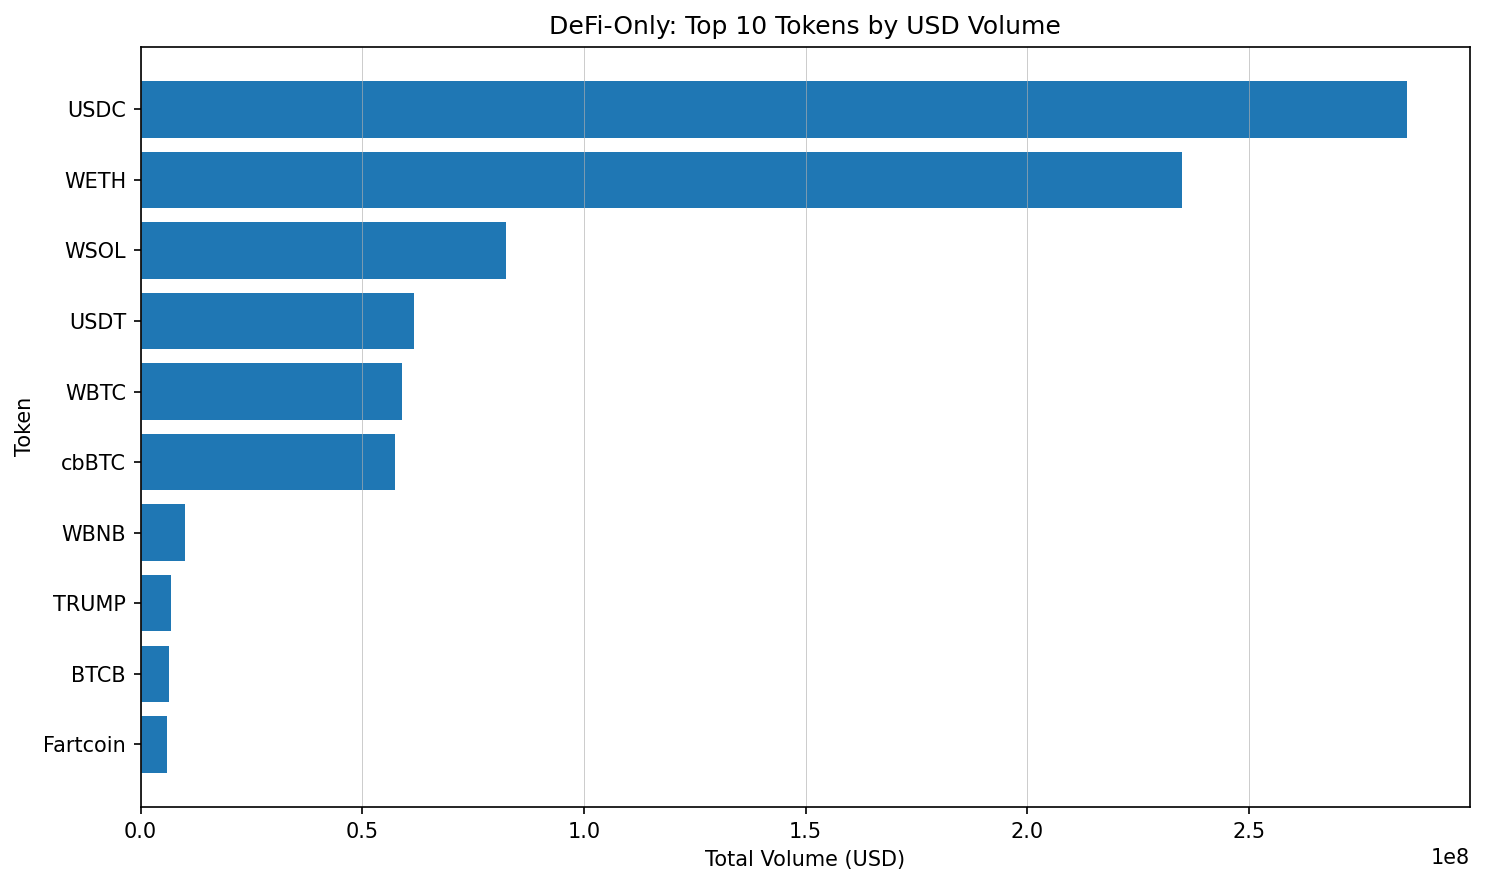

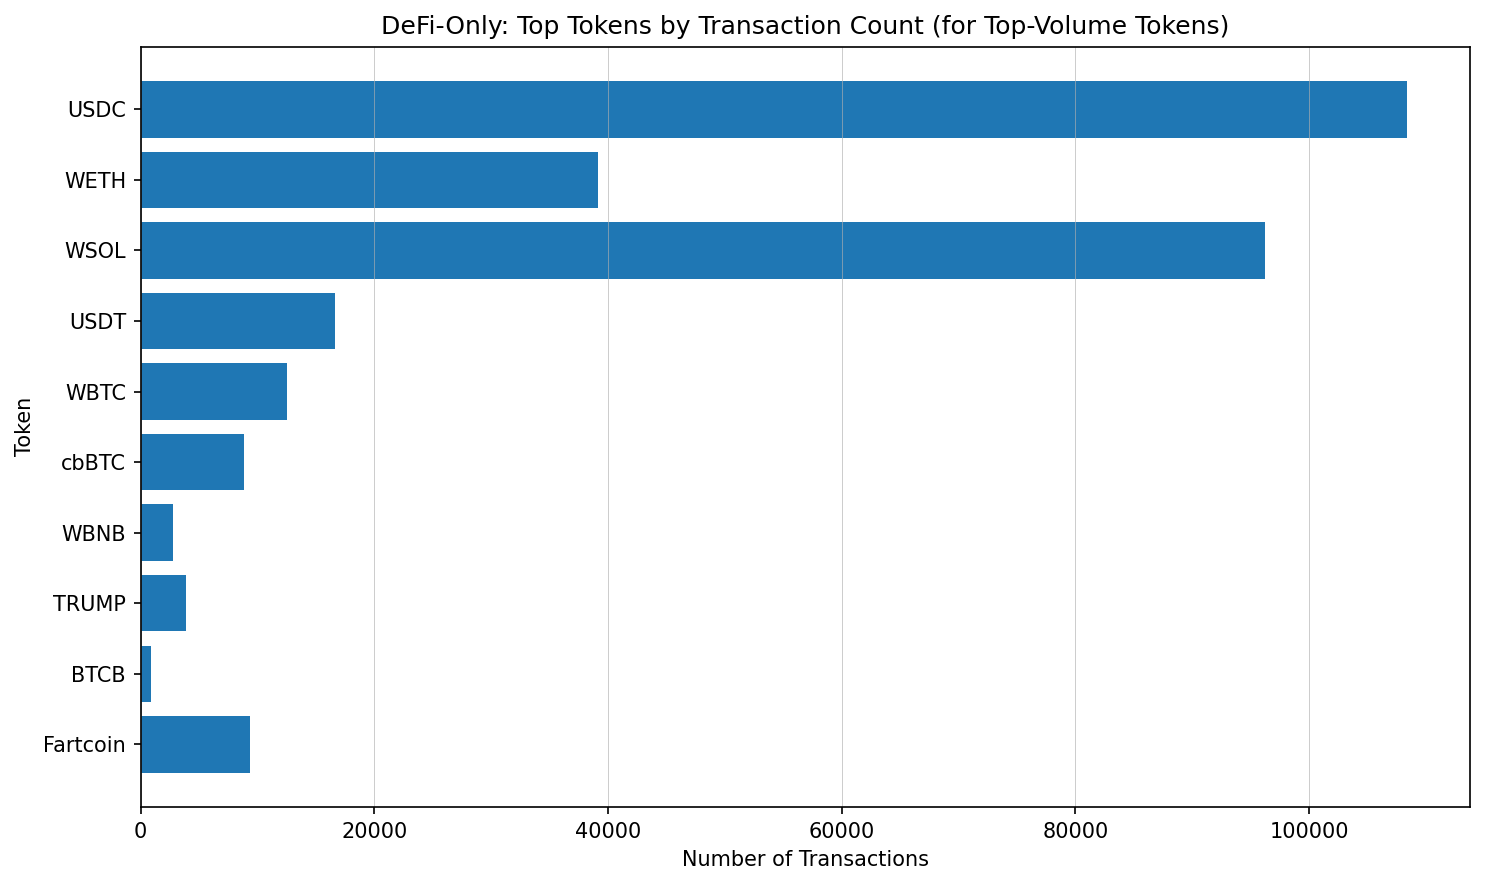

/var/folders/y_/t9805k810jg45bb4qbmvbjxr0000gn/T/ipykernel_13061/2093996651.py:34: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_defi["minute"] = df_defi["timestamp"].dt.floor("T")


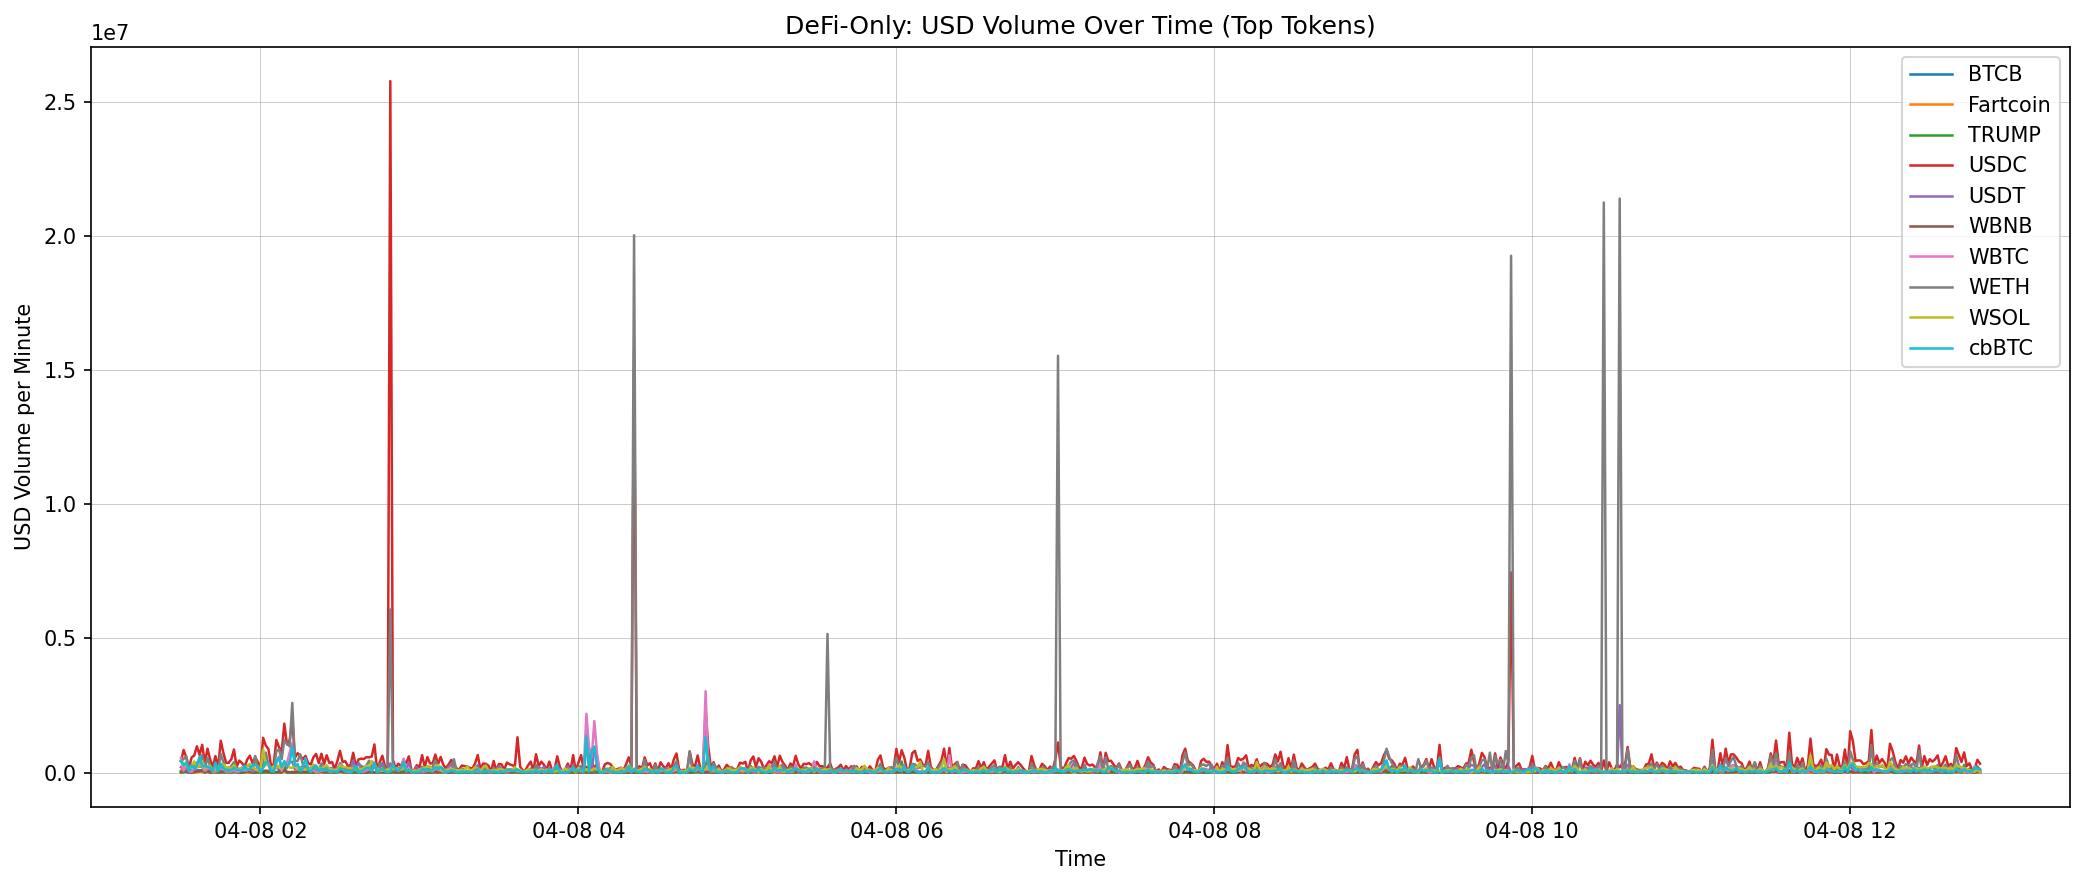

In [39]:

class_map = dict(zip(entities_df["entity"], entities_df["classification"]))
df["from_class"] = df["from_entity"].map(class_map)
df["to_class"]   = df["to_entity"].map(class_map)

defi_mask = (df["from_class"] == "DeFi") | (df["to_class"] == "DeFi")
df_defi = df[defi_mask].copy()

token_vol = df_defi.groupby("token")["usd"].sum().sort_values(ascending=False)
token_cnt = df_defi["token"].value_counts()

top_tokens = token_vol.head(10).index  


plt.figure(figsize=(10,6), dpi=150)
plt.barh(token_vol.head(10).index, token_vol.head(10).values)
plt.title("DeFi-Only: Top 10 Tokens by USD Volume")
plt.xlabel("Total Volume (USD)")
plt.ylabel("Token")
plt.gca().invert_yaxis()
plt.grid(axis="x", linewidth=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6), dpi=150)
plt.barh(token_cnt.loc[top_tokens].index, token_cnt.loc[top_tokens].values)
plt.title("DeFi-Only: Top Tokens by Transaction Count (for Top-Volume Tokens)")
plt.xlabel("Number of Transactions")
plt.ylabel("Token")
plt.gca().invert_yaxis()
plt.grid(axis="x", linewidth=0.3)
plt.tight_layout()
plt.show()

df_defi["minute"] = df_defi["timestamp"].dt.floor("T")
ts_token = (
    df_defi[df_defi["token"].isin(top_tokens)]
    .groupby(["minute","token"])["usd"]
    .sum()
    .unstack(fill_value=0)
)


if hasattr(ts_token.index, "tz") and ts_token.index.tz is not None:
    ts_token.index = ts_token.index.tz_localize(None)

plt.figure(figsize=(14,6), dpi=150)
for t in ts_token.columns:
    plt.plot(ts_token.index.to_numpy(), ts_token[t].values, label=t, linewidth=1.2)

plt.title("DeFi-Only: USD Volume Over Time (Top Tokens)")
plt.xlabel("Time")
plt.ylabel("USD Volume per Minute")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Timining

In [40]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.timestamp

0        2025-04-08 12:49:57+00:00
1        2025-04-08 12:49:54+00:00
2        2025-04-08 12:49:51+00:00
3        2025-04-08 12:49:51+00:00
4        2025-04-08 12:49:50+00:00
                    ...           
436995   2025-04-08 01:30:11+00:00
436996   2025-04-08 01:30:11+00:00
436997   2025-04-08 01:30:11+00:00
436998   2025-04-08 01:30:11+00:00
436999   2025-04-08 01:30:11+00:00
Name: timestamp, Length: 429558, dtype: datetime64[ns, UTC]

Bulding plots by hour in a day 

In [41]:
df['hour'] = df['timestamp'].dt.hour
hourly_counts = df.groupby('hour').size()

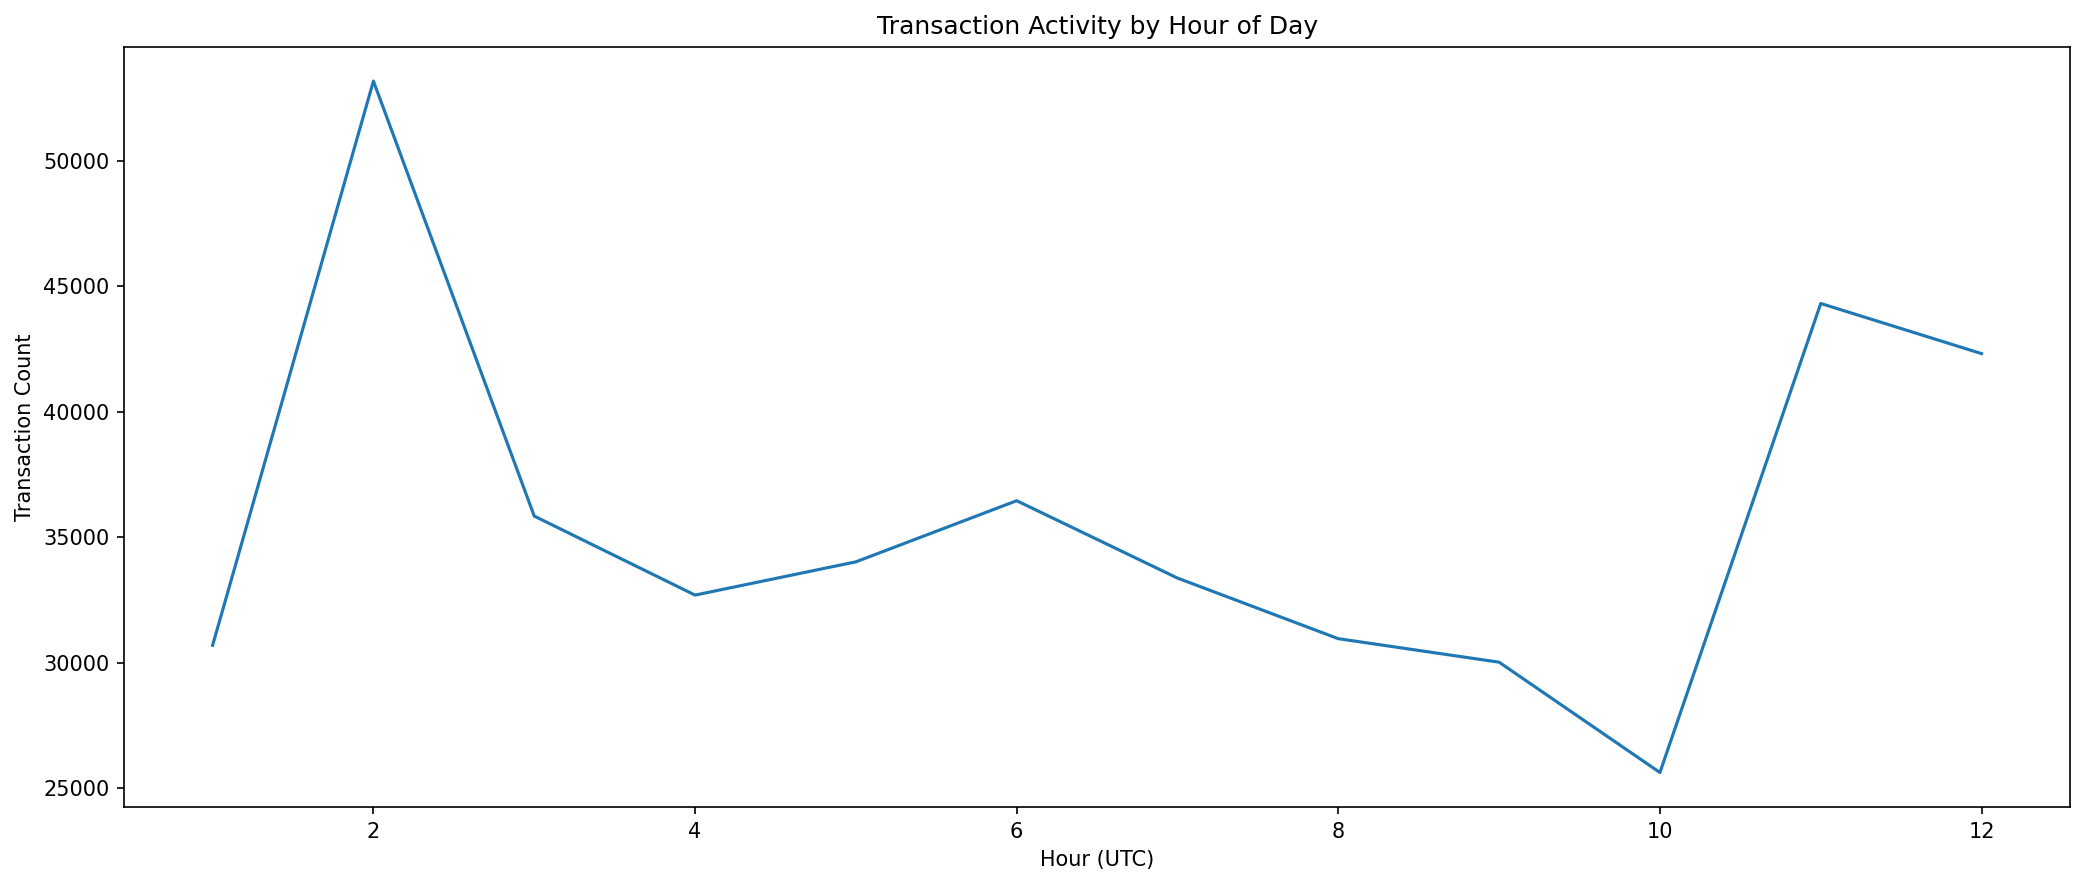

In [42]:
plt.figure(figsize=(14,6), dpi=150)
hourly_counts.plot(kind='line')
plt.title("Transaction Activity by Hour of Day")
plt.xlabel("Hour (UTC)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

In [43]:
hour_chain = df.groupby(['hour','chain']).size().unstack(fill_value=0)

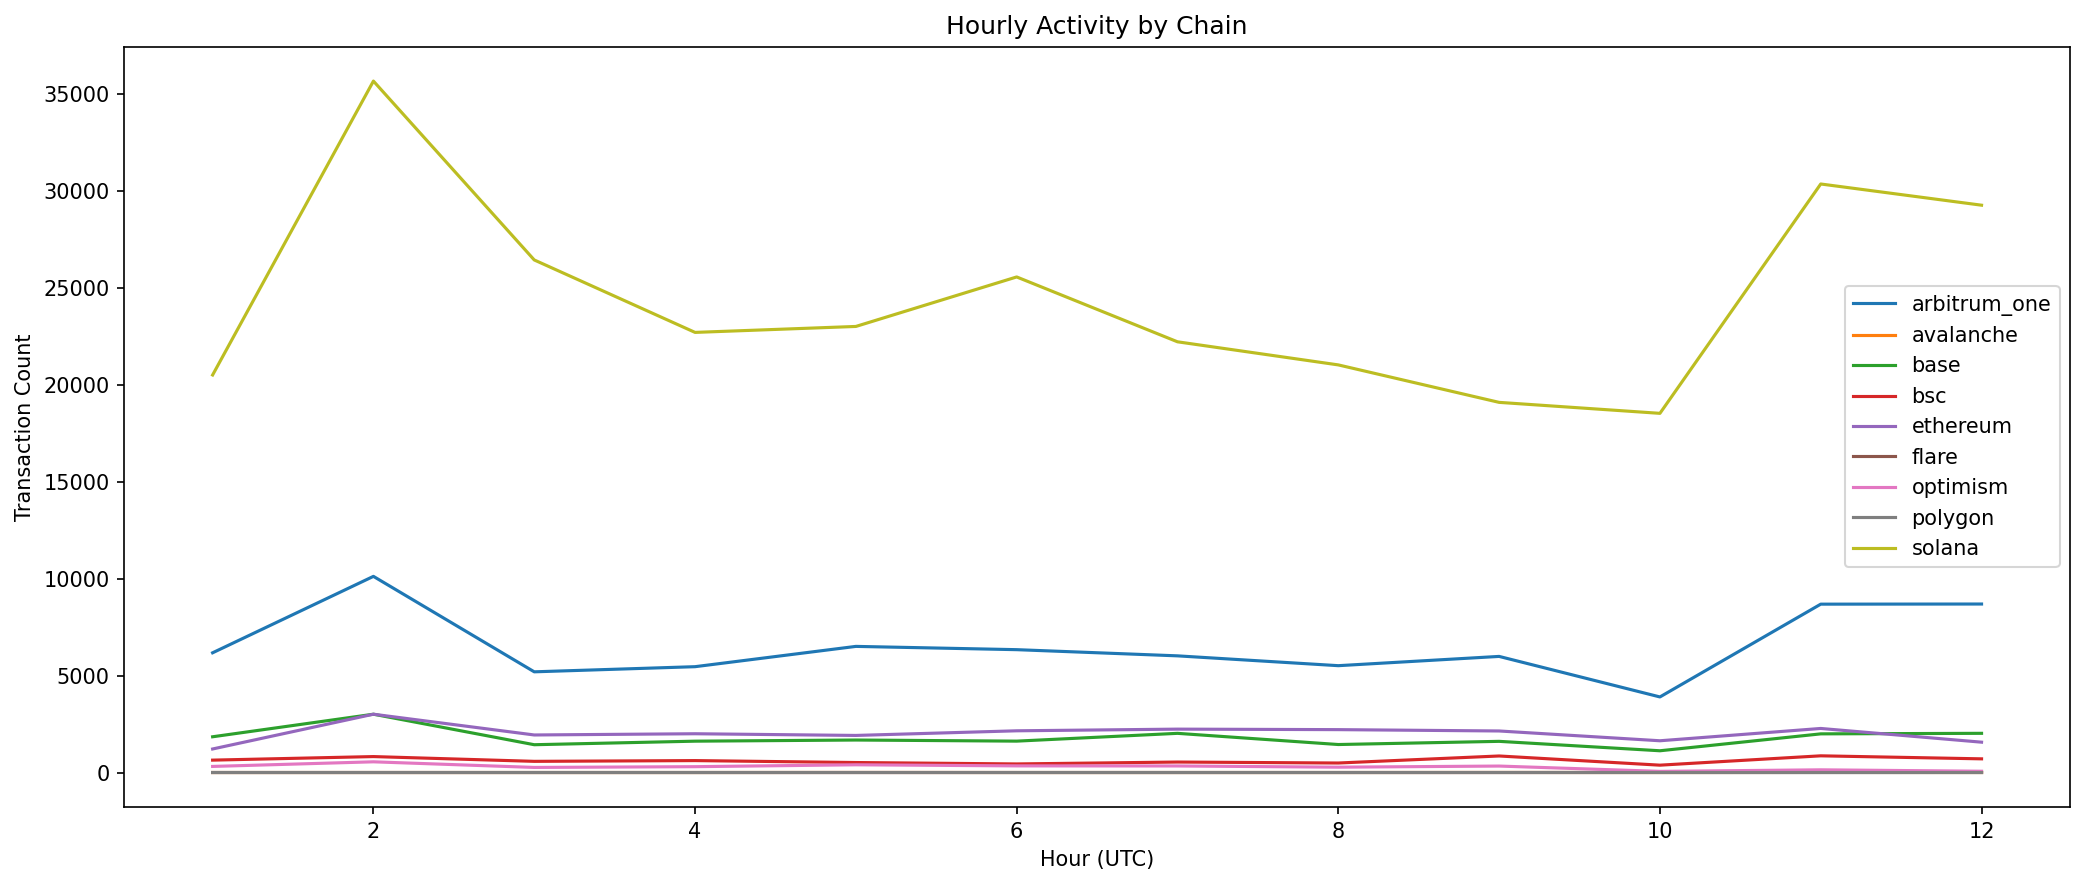

In [44]:
plt.figure(figsize=(14,6), dpi=150)


for chain in hour_chain.columns:
    y = hour_chain[chain].values
    x = hour_chain.index.values
    plt.plot(x, y, label=chain)


plt.title("Hourly Activity by Chain")
plt.xlabel("Hour (UTC)")
plt.ylabel("Transaction Count")
plt.legend()
plt.tight_layout()
plt.show()

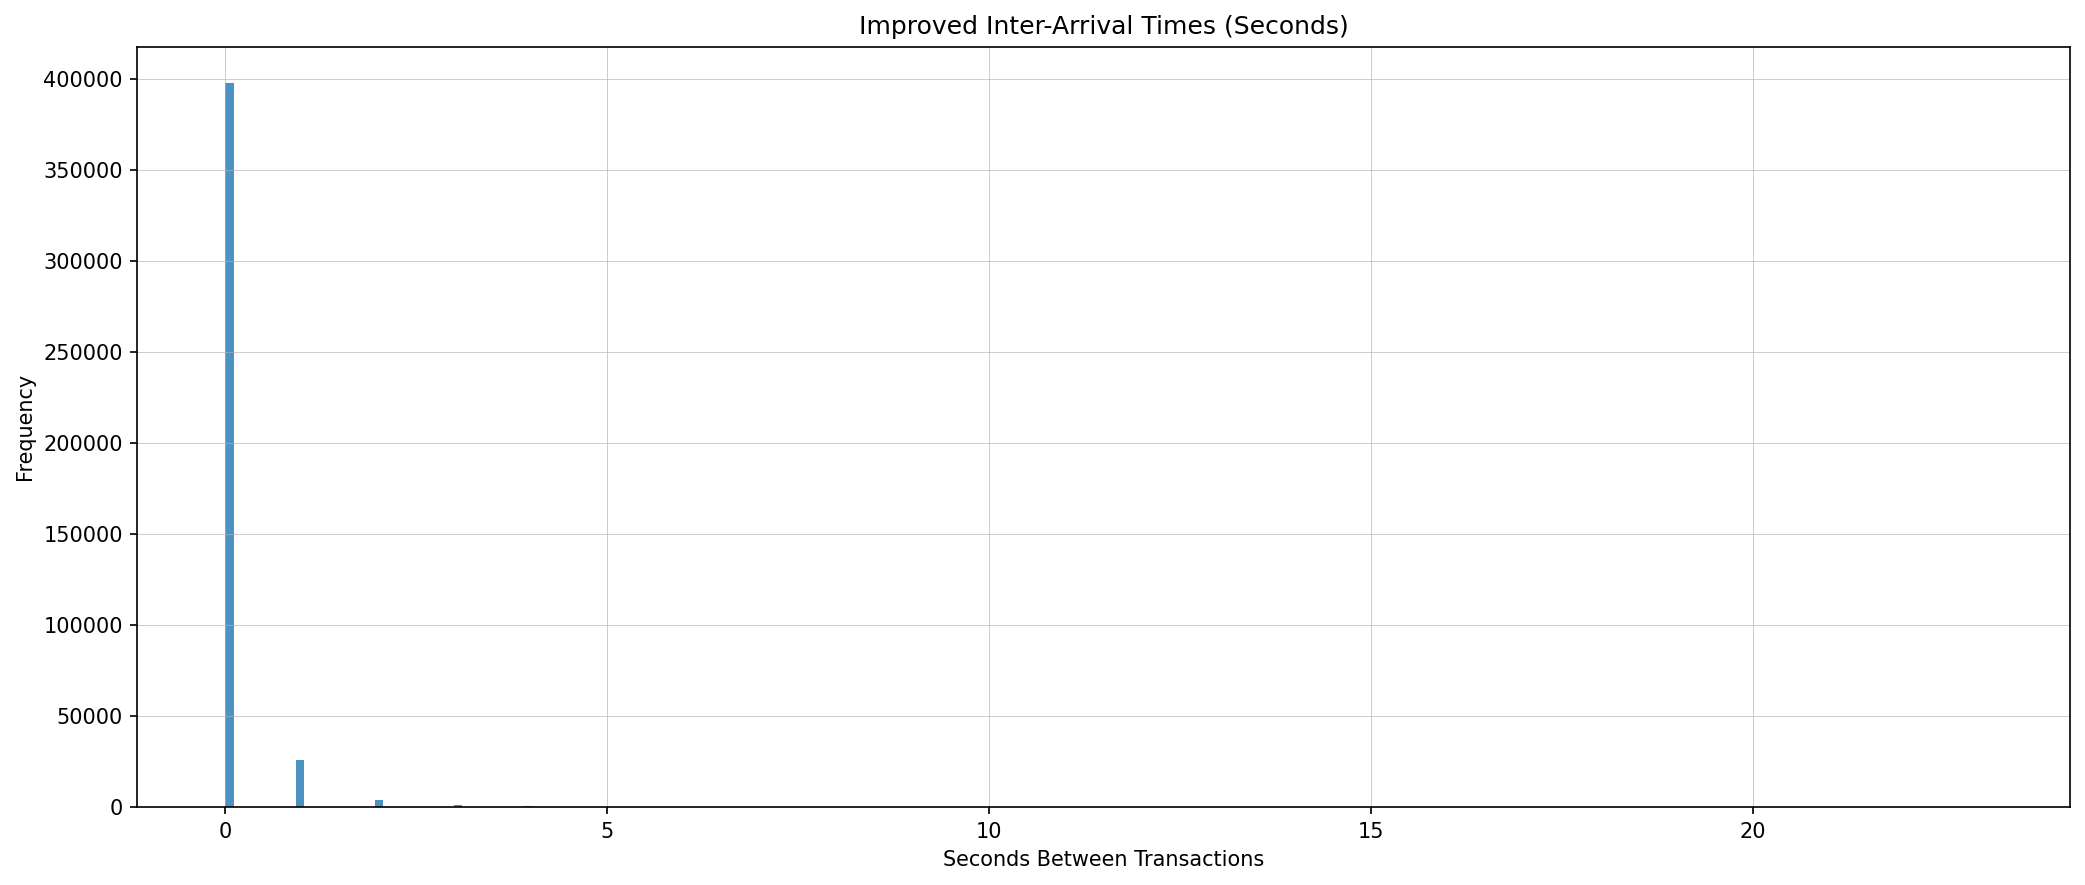

In [45]:
df_sorted = df.sort_values('timestamp')
df_sorted['inter_arrival'] = df_sorted['timestamp'].diff().dt.total_seconds()

inter = df_sorted['inter_arrival'].dropna()

plt.figure(figsize=(14,6), dpi=150)
plt.hist(inter, bins=200, alpha=0.8)
plt.title("Improved Inter-Arrival Times (Seconds)")
plt.xlabel("Seconds Between Transactions")
plt.ylabel("Frequency")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

/var/folders/y_/t9805k810jg45bb4qbmvbjxr0000gn/T/ipykernel_13061/4259447324.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts = df.set_index('timestamp').resample('5T').size()


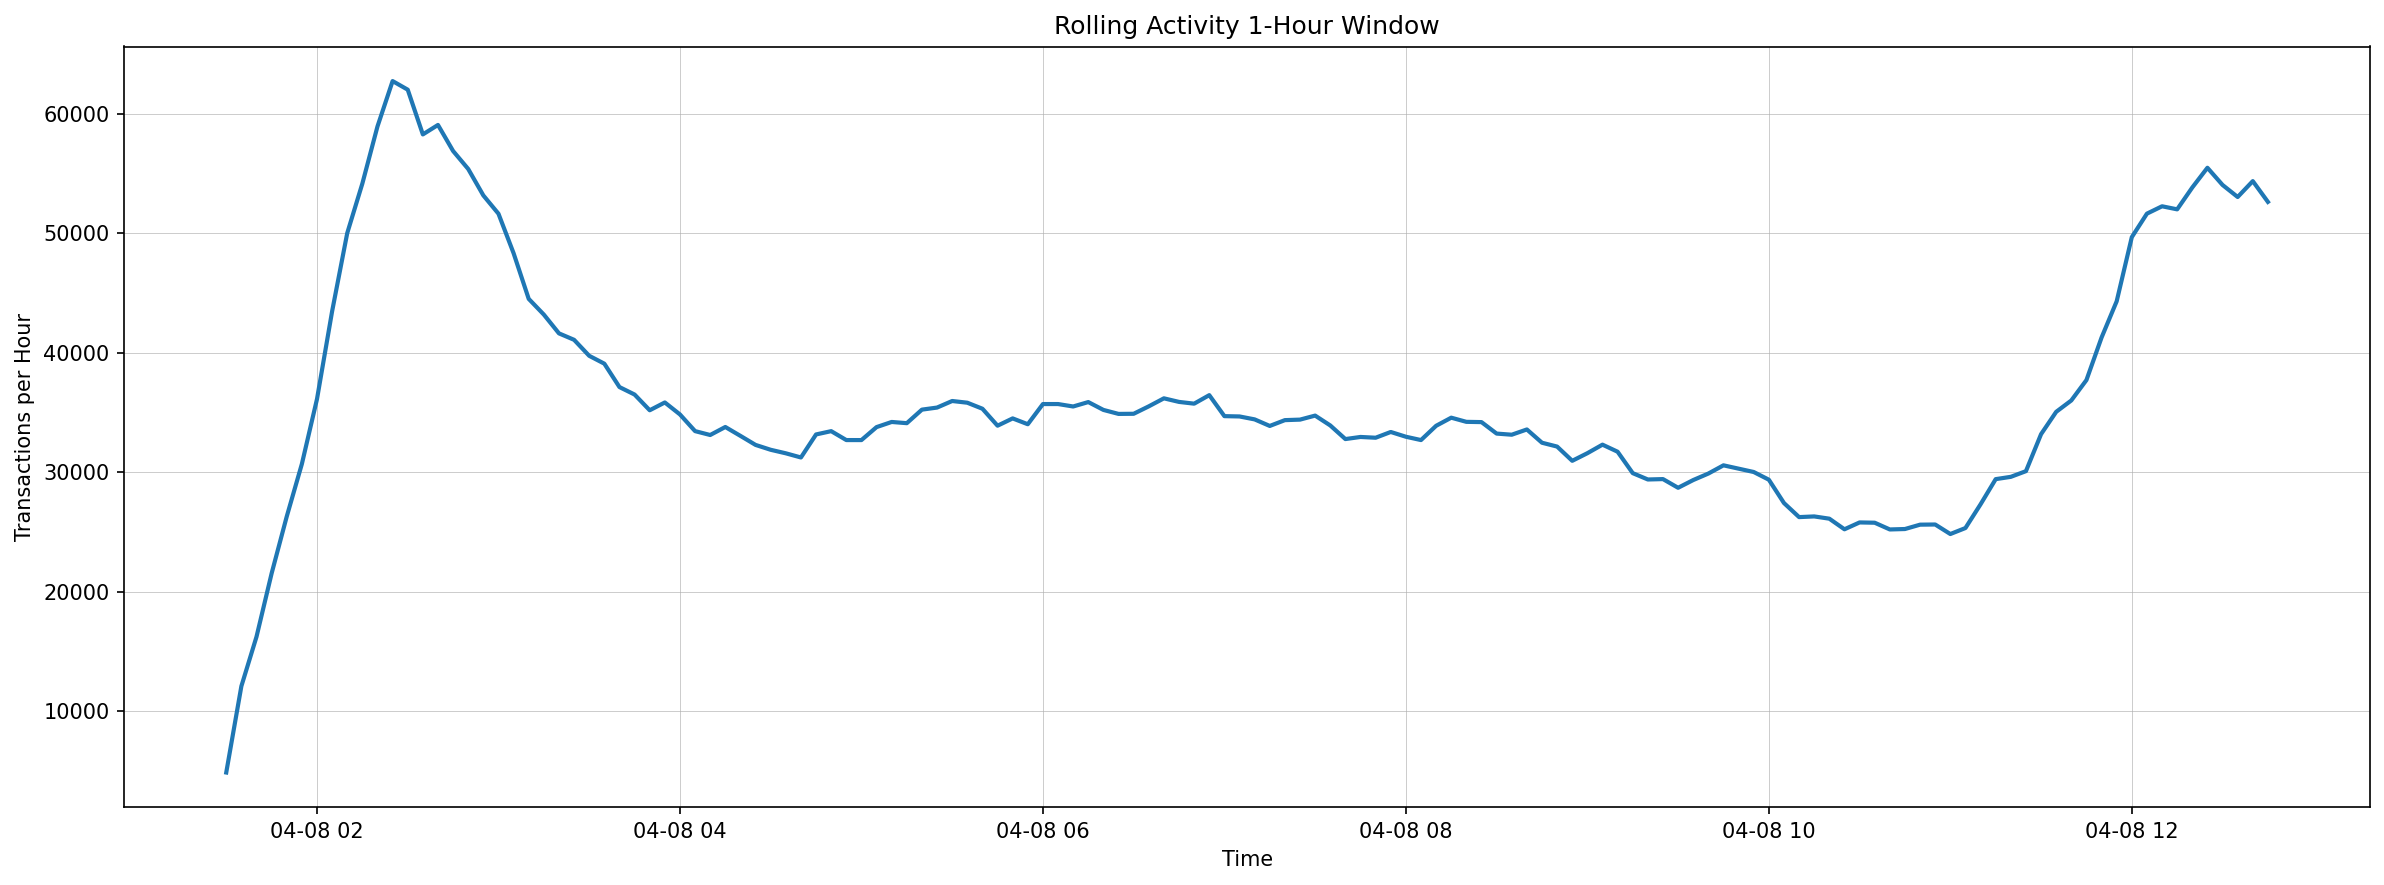

In [46]:
ts = df.set_index('timestamp').resample('5T').size()
rolling = ts.rolling(12, min_periods=1).sum()
rolling.index = rolling.index.tz_localize(None)

plt.figure(figsize=(16,6), dpi=150)
plt.plot(rolling.index.to_numpy(), rolling.values, linewidth=2)
plt.title("Rolling Activity 1-Hour Window")
plt.xlabel("Time")
plt.ylabel("Transactions per Hour")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

/var/folders/y_/t9805k810jg45bb4qbmvbjxr0000gn/T/ipykernel_13061/2892263918.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['minute'] = df['timestamp'].dt.floor('T')


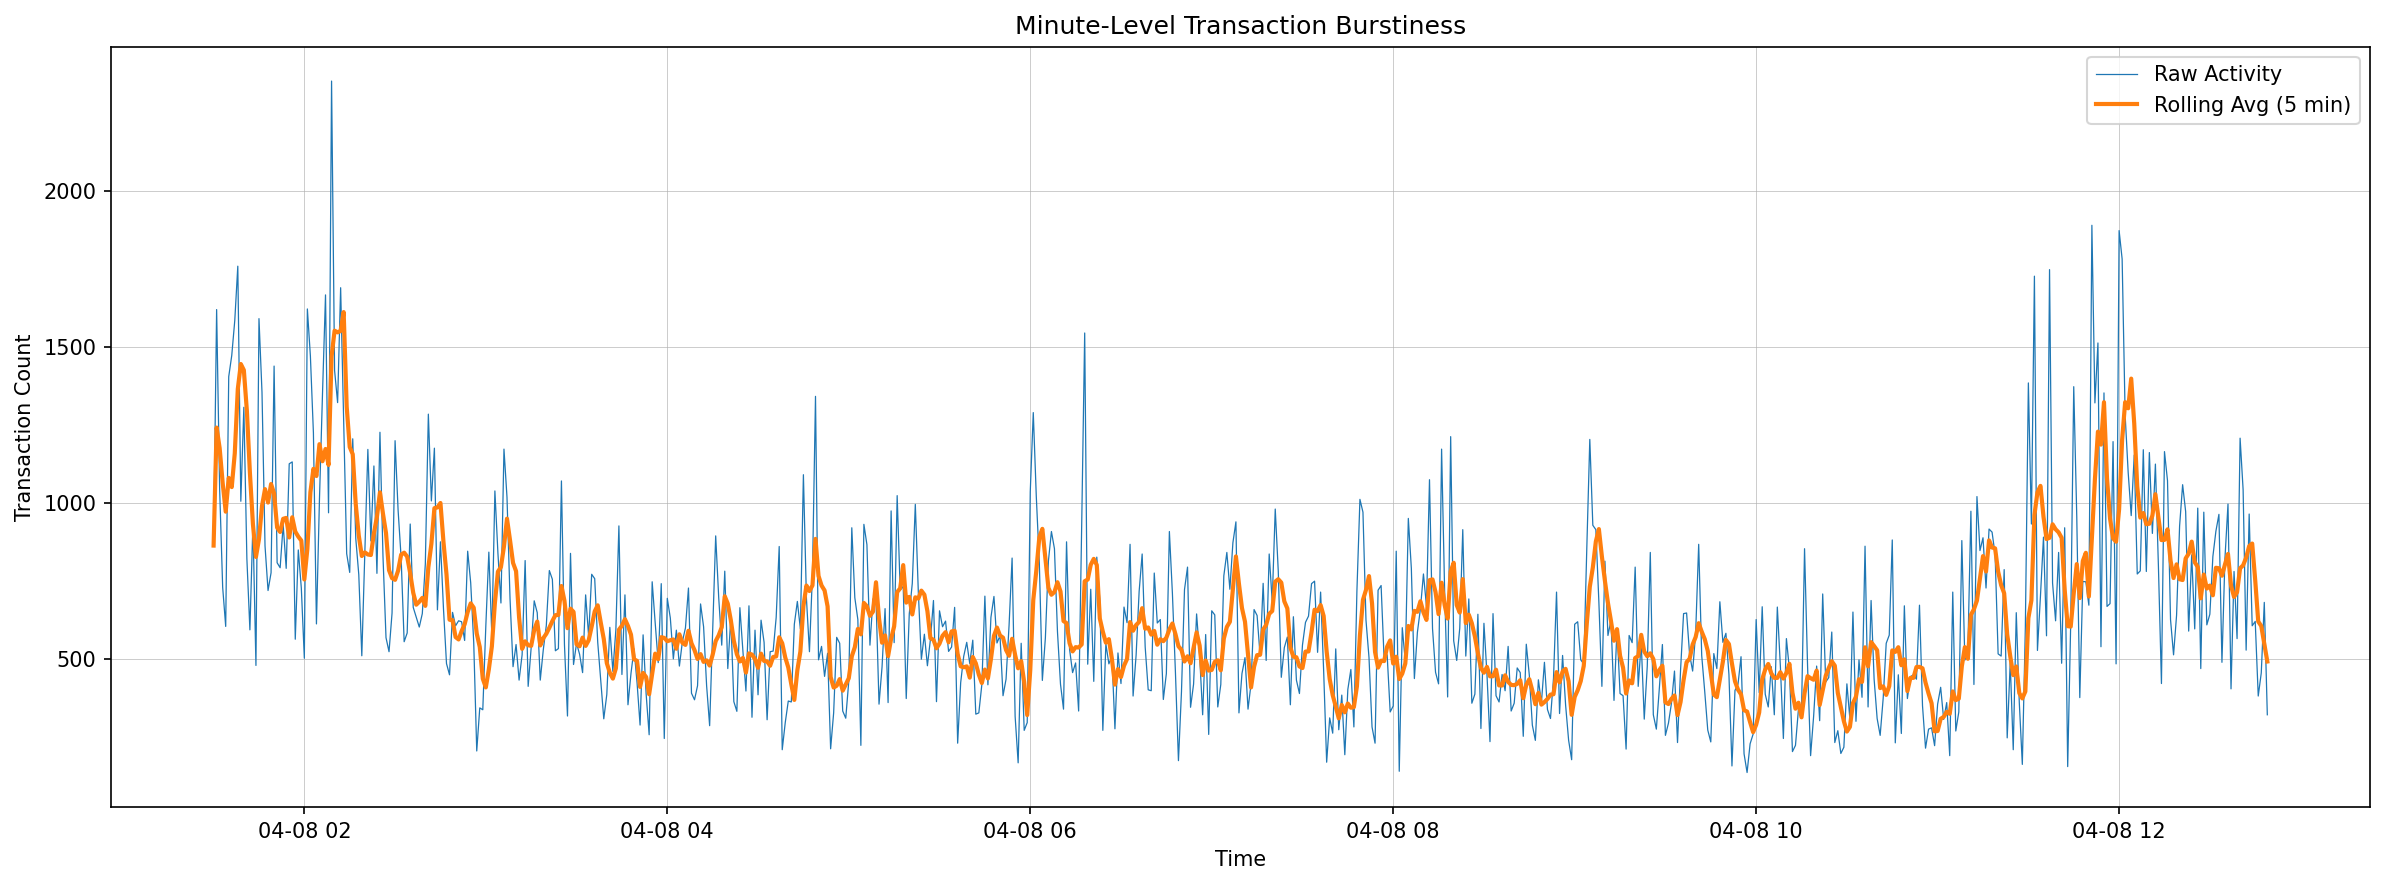

In [47]:

df['minute'] = df['timestamp'].dt.floor('T')
minute_counts = df.groupby('minute').size()
minute_counts.index = pd.to_datetime(minute_counts.index).tz_localize(None)
rolling = minute_counts.rolling(5, min_periods=1).mean()


plt.figure(figsize=(16,6), dpi=150)

plt.plot(minute_counts.index.to_numpy(), minute_counts.values, linewidth=0.6, label="Raw Activity")
plt.plot(rolling.index.to_numpy(), rolling.values, linewidth=2.0, label="Rolling Avg (5 min)")

plt.title("Minute-Level Transaction Burstiness")
plt.xlabel("Time")
plt.ylabel("Transaction Count")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()


DeFi-Only Analysis:

In [48]:
token_stats = (
    df_defi.groupby("token")
    .agg(
        tx_count=("token", "size"),
        total_usd=("usd", "sum"),
        avg_usd=("usd", "mean")
    )
    .sort_values("total_usd", ascending=False)
)

top_tokens = token_stats.head(10)

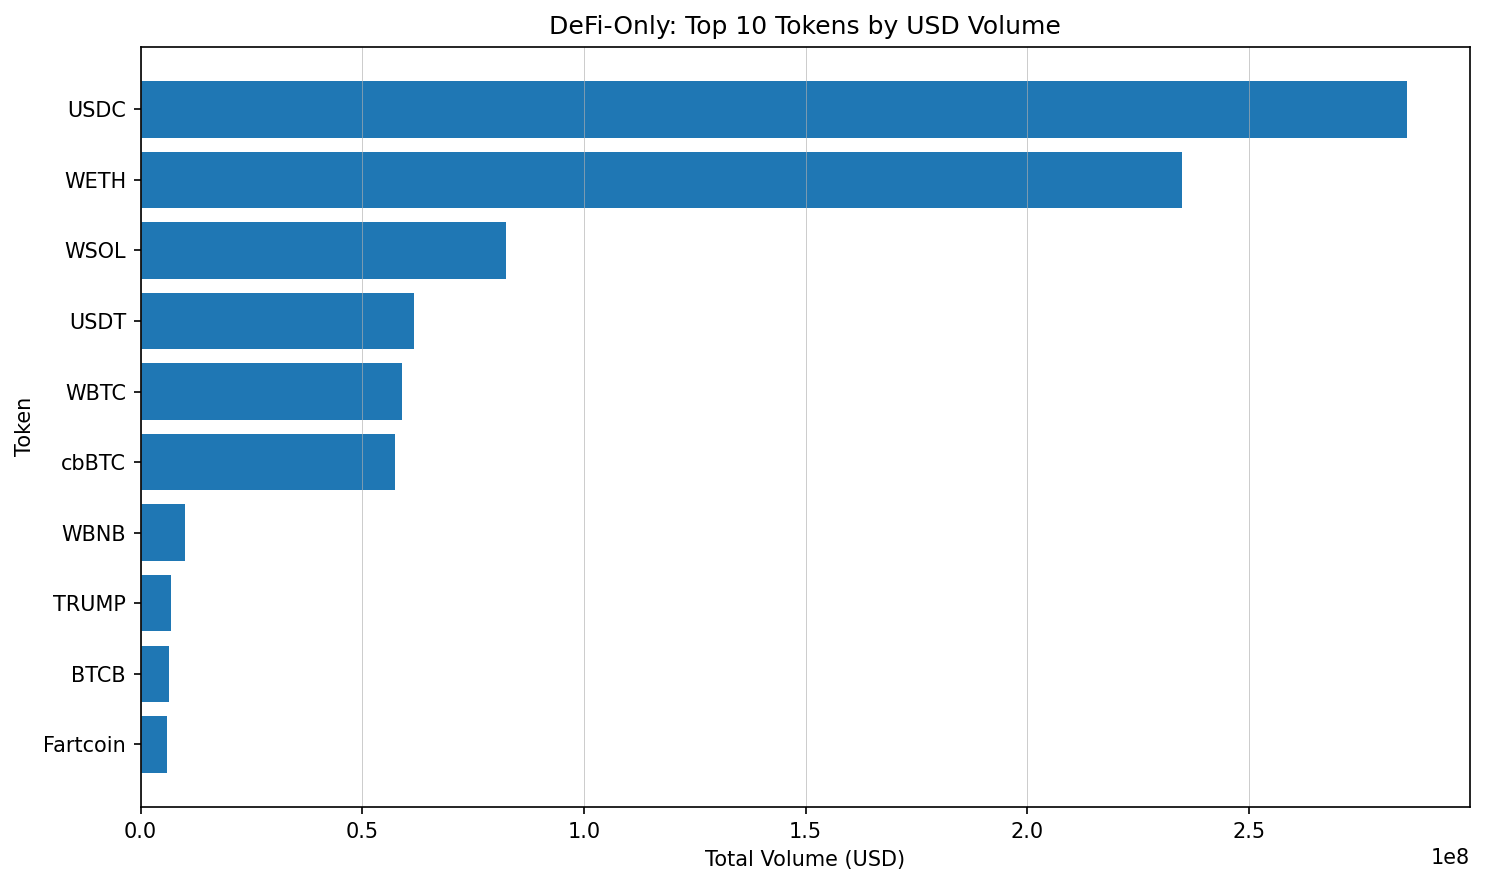

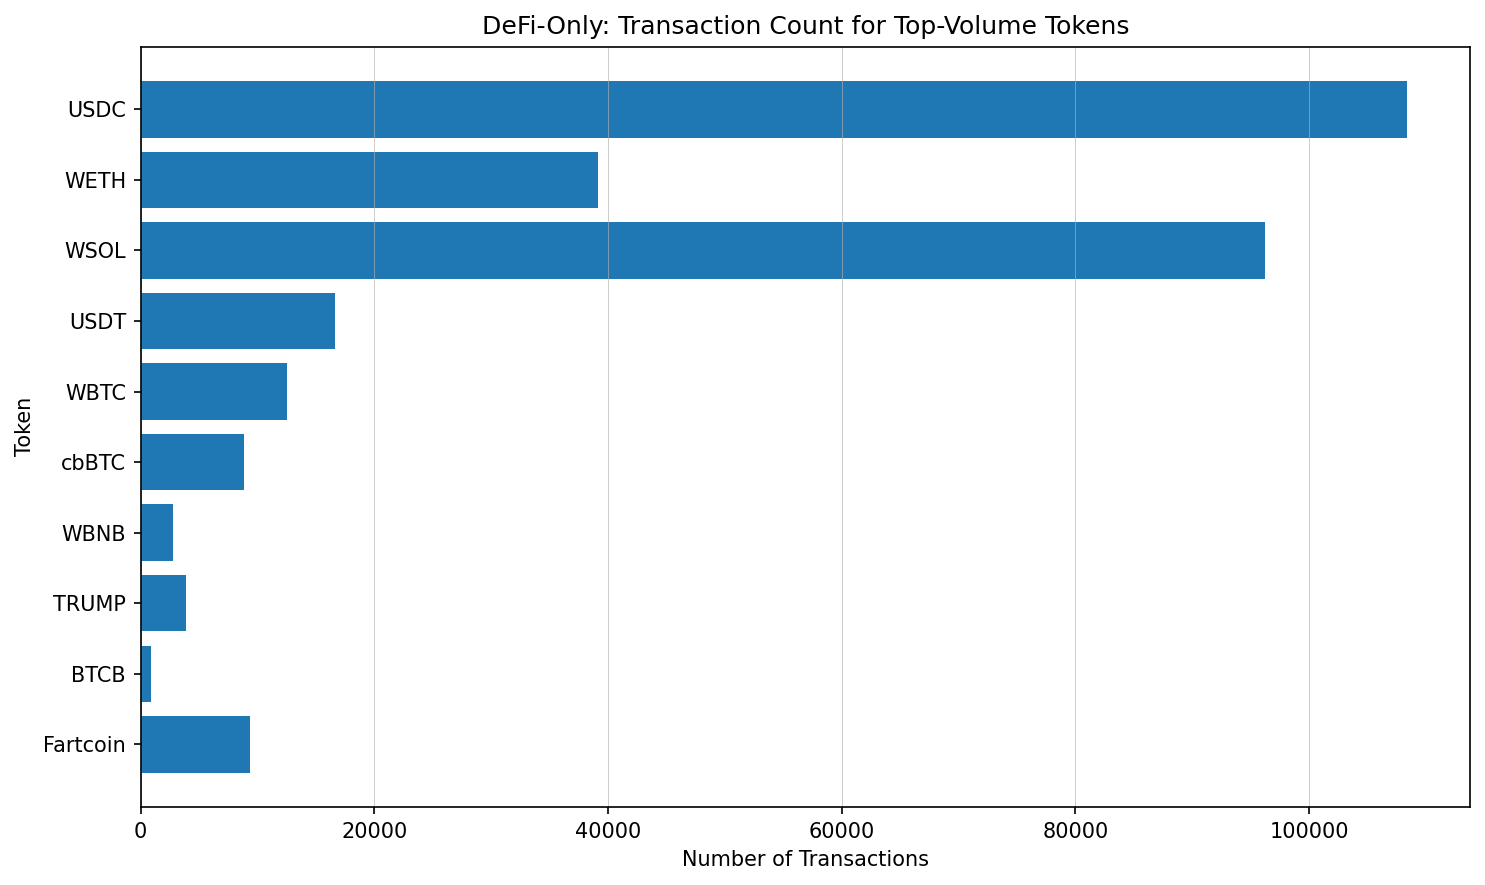

In [49]:

plt.figure(figsize=(10,6), dpi=150)
plt.barh(top_tokens.index, top_tokens["total_usd"].values)
plt.title("DeFi-Only: Top 10 Tokens by USD Volume")
plt.xlabel("Total Volume (USD)")
plt.ylabel("Token")
plt.gca().invert_yaxis()
plt.grid(axis="x", linewidth=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6), dpi=150)
plt.barh(top_tokens.index, top_tokens["tx_count"].values)
plt.title("DeFi-Only: Transaction Count for Top-Volume Tokens")
plt.xlabel("Number of Transactions")
plt.ylabel("Token")
plt.gca().invert_yaxis()
plt.grid(axis="x", linewidth=0.3)
plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import numpy as np


entities = pd.unique(df[["from_entity", "to_entity"]].values.ravel())
entities = [e for e in entities if pd.notna(e)]
entities_df = pd.DataFrame({"entity": entities})
entities_df["classification"] = entities_df["entity"].apply(classify_entity)

class_map = dict(zip(entities_df["entity"], entities_df["classification"]))
df["from_class"] = df["from_entity"].map(class_map)
df["to_class"]   = df["to_entity"].map(class_map)

is_winter_from = df["from_entity"].isin(["Wintermute", "Rizzolver (Wintermute)"])
is_winter_to   = df["to_entity"].isin(["Wintermute", "Rizzolver (Wintermute)"])
is_defi_from   = df["from_class"].eq("DeFi")
is_defi_to     = df["to_class"].eq("DeFi")

mask_defi = (is_winter_from & is_defi_to) | (is_winter_to & is_defi_from)
df_defi = df[mask_defi].copy()
def get_defi_entity(row):
    if row["from_class"] == "DeFi":
        return row["from_entity"]
    if row["to_class"] == "DeFi":
        return row["to_entity"]
    return np.nan

df_defi["defi_entity"] = df_defi.apply(get_defi_entity, axis=1)


In [51]:
chain_stats = (
    df_defi.groupby("chain")
    .agg(
        tx_count=("chain", "size"),
        total_usd=("usd", "sum"),
        avg_usd=("usd", "mean")
    )
    .sort_values("total_usd", ascending=False)
)

print(chain_stats)


              tx_count     total_usd       avg_usd
chain                                             
ethereum         15948  4.059755e+08  25456.203932
solana          250314  1.826917e+08    729.850004
base             20582  1.459003e+08   7088.733063
arbitrum_one     65306  5.595431e+07    856.801929
bsc               7274  3.183190e+07   4376.119781
optimism          3320  6.777426e+06   2041.393473


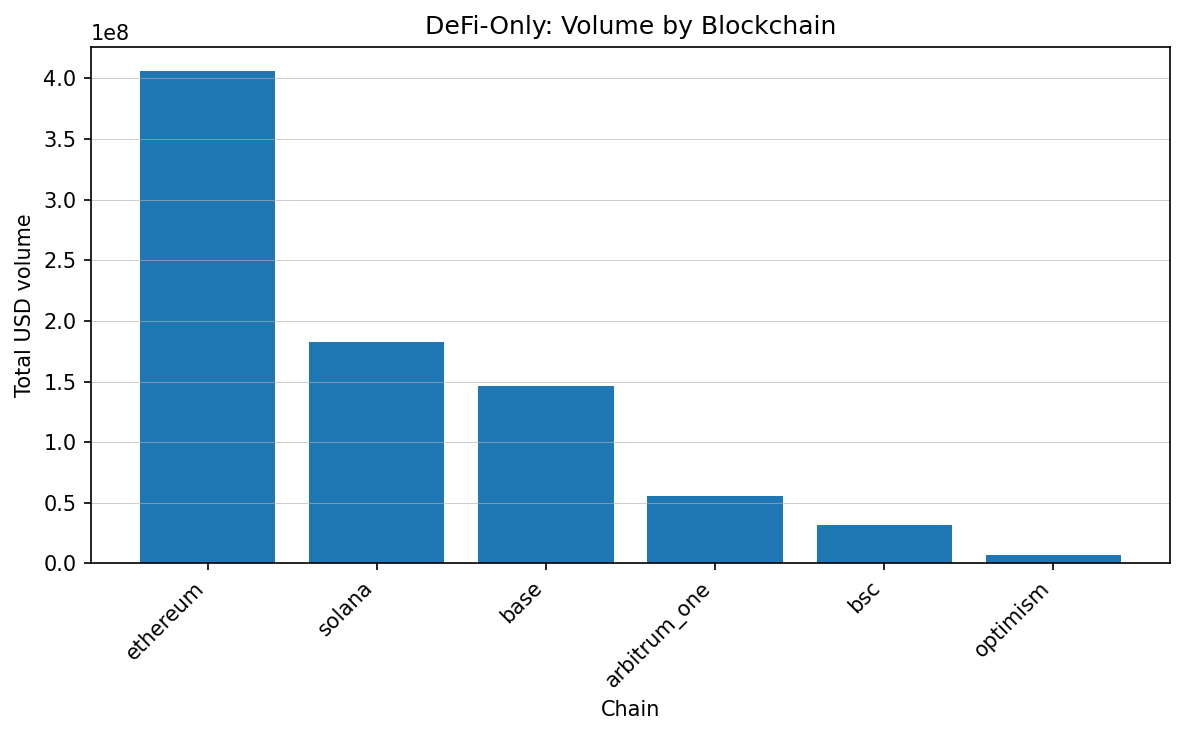

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5), dpi=150)
plt.bar(chain_stats.index, chain_stats["total_usd"])
plt.title("DeFi-Only: Volume by Blockchain")
plt.xlabel("Chain")
plt.ylabel("Total USD volume")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linewidth=0.3)
plt.tight_layout()
plt.show()


In [53]:
top_platforms = platform_stats.head(20)

plt.figure(figsize=(10,6), dpi=150)
plt.barh(top_platforms.index, top_platforms["total_usd"])
plt.title("DeFi-Only: Top 10 DeFi Platforms by USD Volume")
plt.xlabel("Total USD volume")
plt.ylabel("DeFi platform")
plt.gca().invert_yaxis()
plt.grid(axis="x", linewidth=0.3)
plt.tight_layout()
plt.show()


NameError: name 'platform_stats' is not defined

In [ ]:
import numpy as np

idx = pd.to_datetime(hourly.index)

if getattr(idx, "tz", None) is not None:
    idx = idx.tz_localize(None)

x = idx.to_numpy()

y_tx  = hourly["tx_count"].to_numpy()
y_vol = hourly["total_usd"].to_numpy()


In [ ]:

smooth_tx  = pd.Series(y_tx, index=idx).rolling(3, center=True, min_periods=1).mean().to_numpy()
smooth_vol = pd.Series(y_vol, index=idx).rolling(3, center=True, min_periods=1).mean().to_numpy()
active_tx  = y_tx  > 0
active_vol = y_vol > 0


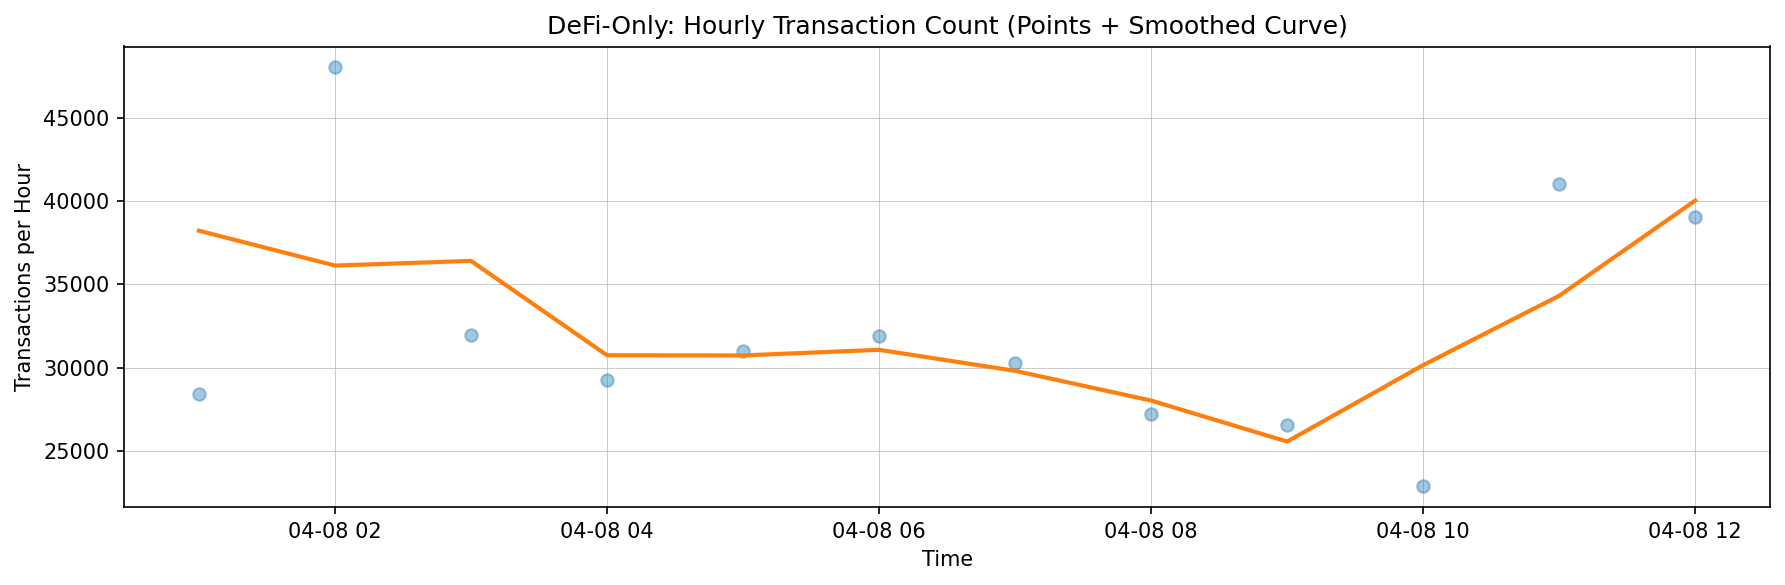

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4), dpi=150)


plt.plot(x[active_tx], y_tx[active_tx], marker="o", linestyle="none", alpha=0.4)


plt.plot(x[active_tx], smooth_tx[active_tx], linewidth=2)

plt.title("DeFi-Only: Hourly Transaction Count (Points + Smoothed Curve)")
plt.xlabel("Time")
plt.ylabel("Transactions per Hour")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()


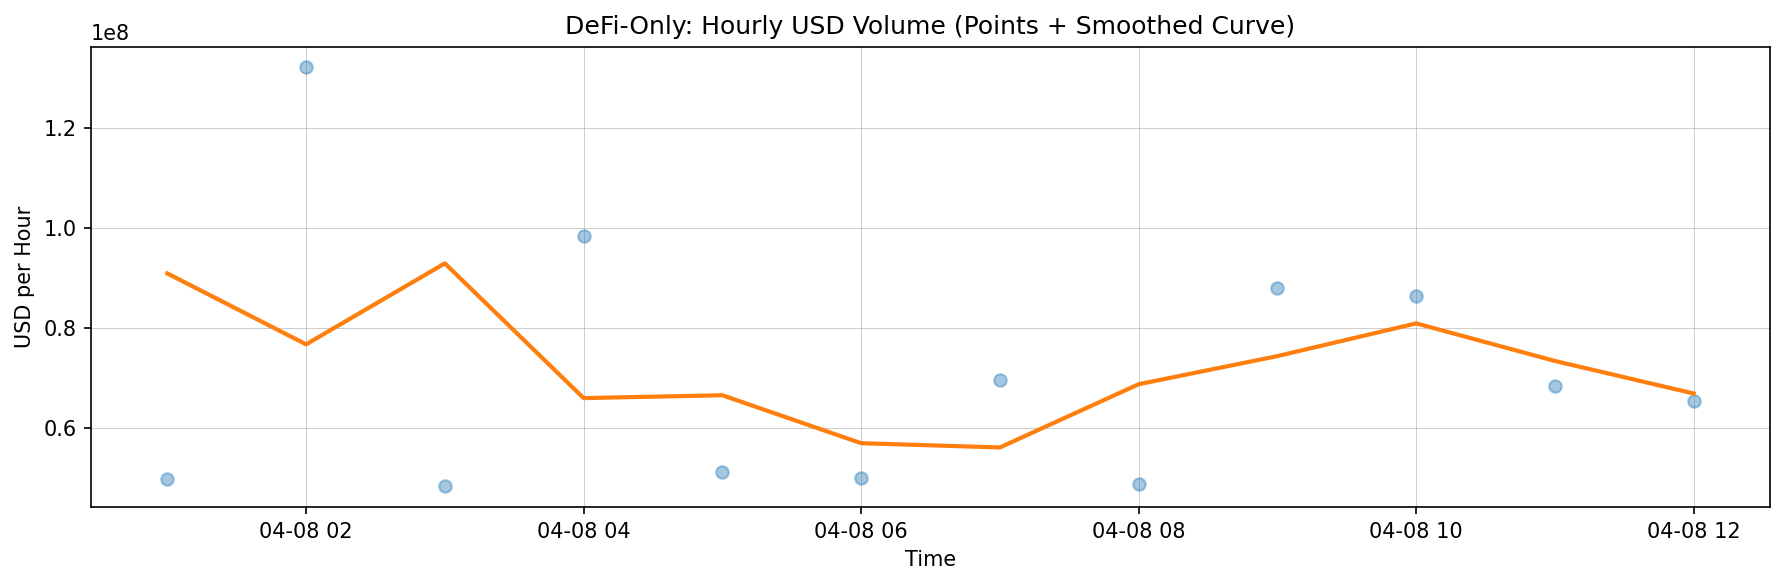

In [ ]:
plt.figure(figsize=(12,4), dpi=150)


plt.plot(x[active_vol], y_vol[active_vol], marker="o", linestyle="none", alpha=0.4)


plt.plot(x[active_vol], smooth_vol[active_vol], linewidth=2)

plt.title("DeFi-Only: Hourly USD Volume (Points + Smoothed Curve)")
plt.xlabel("Time")
plt.ylabel("USD per Hour")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()


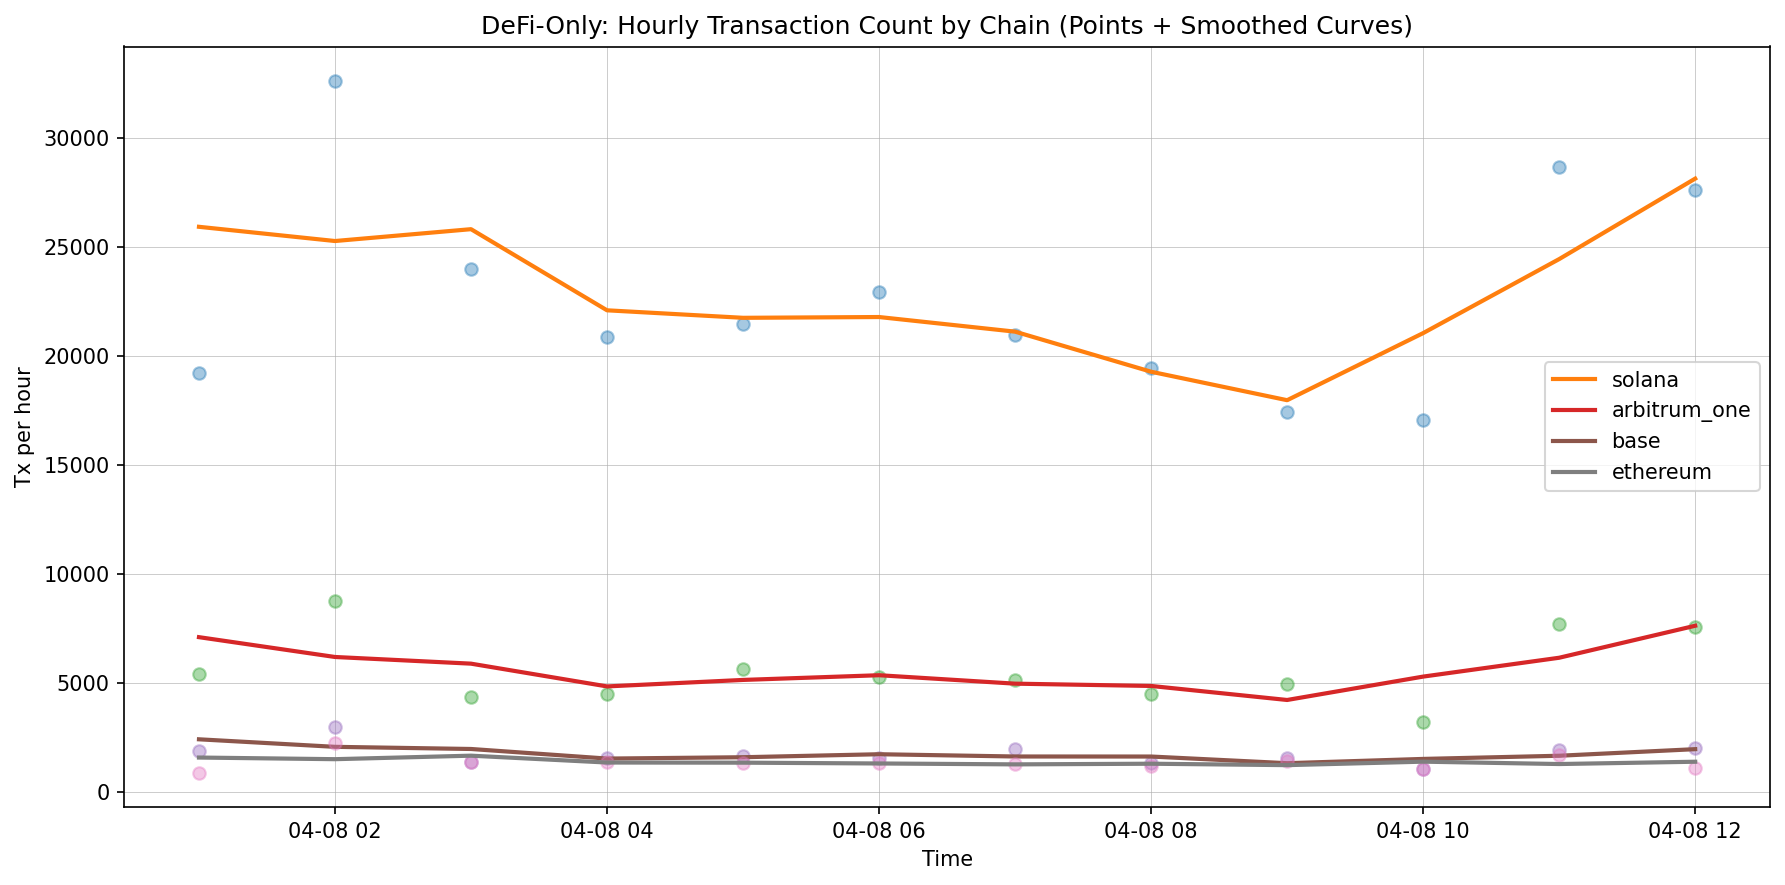

In [ ]:

df_defi_time = df_defi.copy()
df_defi_time["timestamp"] = pd.to_datetime(df_defi_time["timestamp"], errors="coerce")
df_defi_time = df_defi_time.set_index("timestamp").sort_index()


hourly_chain = (
    df_defi_time
    .groupby([pd.Grouper(freq="1h"), "chain"])
    .size()
    .unstack(fill_value=0)  
)


idx = pd.to_datetime(hourly_chain.index)
if getattr(idx, "tz", None) is not None:
    idx = idx.tz_localize(None)

x = idx.to_numpy()

total_per_chain = hourly_chain.sum(axis=0).sort_values(ascending=False)
top_chains = total_per_chain.head(4).index  

plt.figure(figsize=(12,6), dpi=150)

for chain in top_chains:
    y = hourly_chain[chain].to_numpy()
   
    smooth = (
        pd.Series(y, index=idx)
        .rolling(3, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )
    active = y > 0 

    # points
    plt.plot(x[active], y[active], marker="o", linestyle="none", alpha=0.4)
    # smooth curve
    plt.plot(x[active], smooth[active], linewidth=2, label=chain)

plt.title("DeFi-Only: Hourly Transaction Count by Chain (Points + Smoothed Curves)")
plt.xlabel("Time")
plt.ylabel("Tx per hour")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()


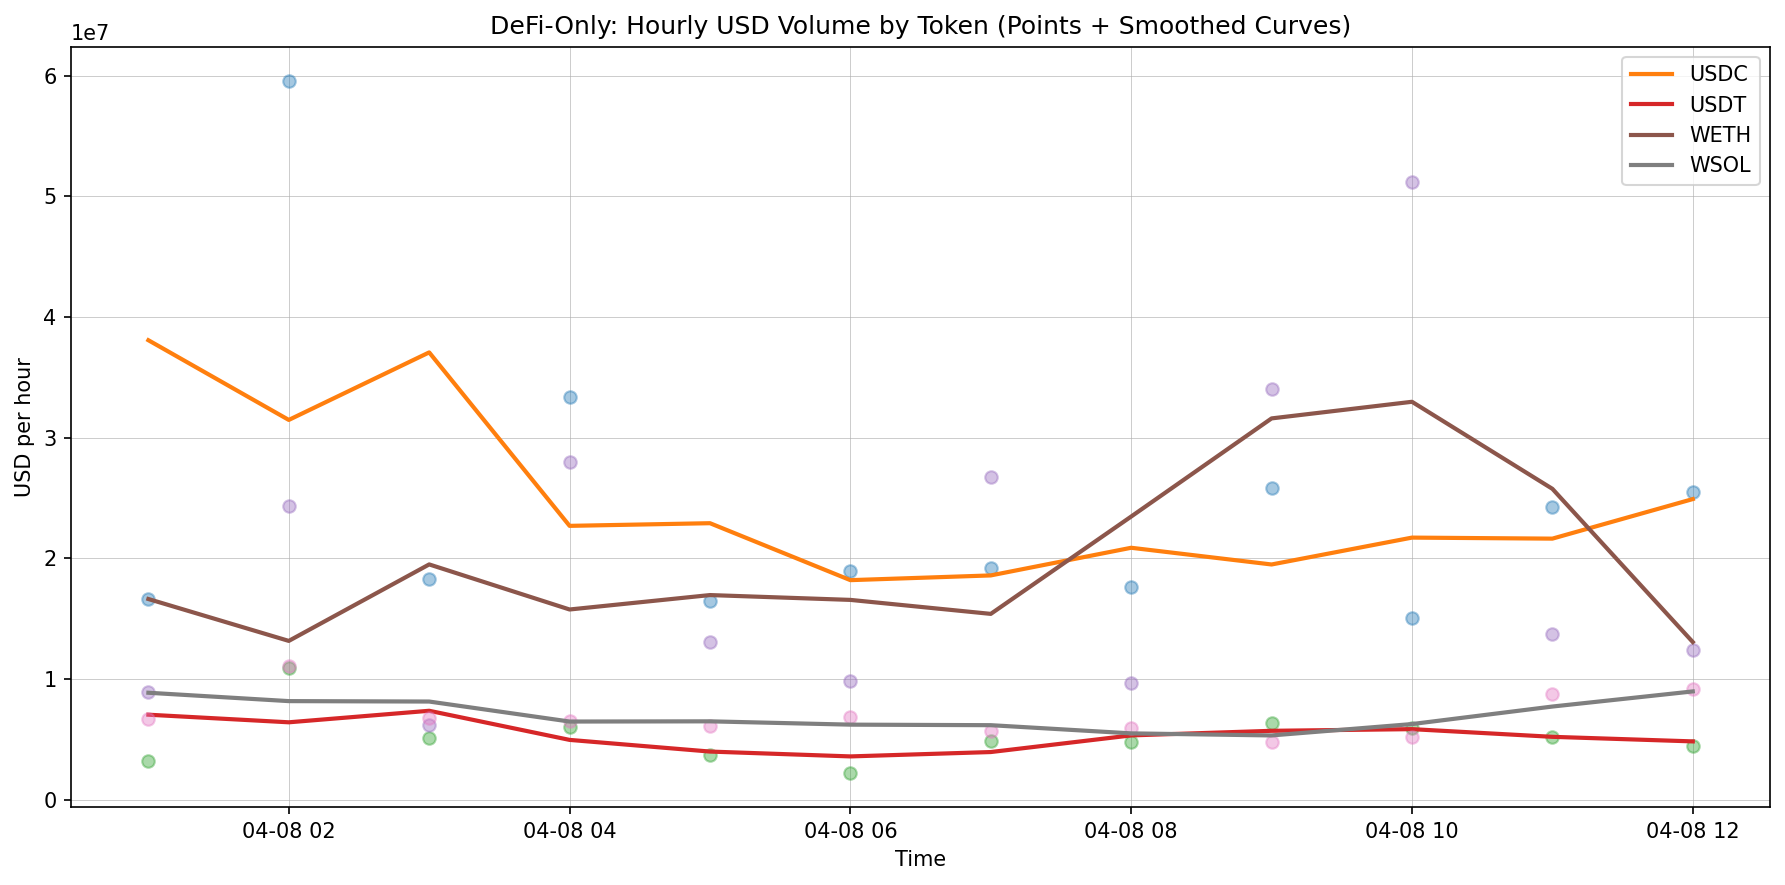

In [ ]:

df_defi_time = df_defi.copy()
df_defi_time["timestamp"] = pd.to_datetime(df_defi_time["timestamp"], errors="coerce")
df_defi_time = df_defi_time.set_index("timestamp").sort_index()


token_vol = df_defi_time.groupby("token")["usd"].sum().sort_values(ascending=False)
top_tokens = token_vol.head(4).index   


hourly_token = (
    df_defi_time[df_defi_time["token"].isin(top_tokens)]
    .groupby([pd.Grouper(freq="1h"), "token"])["usd"]
    .sum()
    .unstack(fill_value=0)
)

idx_tok = pd.to_datetime(hourly_token.index)
if getattr(idx_tok, "tz", None) is not None:
    idx_tok = idx_tok.tz_localize(None)

x_tok = idx_tok.to_numpy()

plt.figure(figsize=(12,6), dpi=150)

for t in hourly_token.columns:
    y = hourly_token[t].to_numpy()
    smooth = (
        pd.Series(y, index=idx_tok)
        .rolling(3, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )
    active = y > 0


    plt.plot(x_tok[active], y[active], marker="o", linestyle="none", alpha=0.4)
    
    plt.plot(x_tok[active], smooth[active], linewidth=2, label=t)

plt.title("DeFi-Only: Hourly USD Volume by Token (Points + Smoothed Curves)")
plt.xlabel("Time")
plt.ylabel("USD per hour")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Statistics and EDA


In [ ]:
import pandas as pd
from scipy.stats import kruskal

# df_defi: DeFi-only trades

# pick main chains
main_chains = df_defi["chain"].value_counts().head(4).index
sub = df_defi[df_defi["chain"].isin(main_chains)]

groups = [sub.loc[sub["chain"] == ch, "usd"].values for ch in main_chains]

stat, pval = kruskal(*groups)
print("Kruskal-Wallis H =", stat, "p-value =", pval)
print("Chains:", list(main_chains))


Kruskal-Wallis H = 77050.68387771059 p-value = 0.0
Chains: ['solana', 'arbitrum_one', 'base', 'ethereum']


In [ ]:
from scipy.stats import ttest_ind

# classify each row by "DeFi interaction" vs "CEX interaction"
is_defi = (df["from_class"] == "DeFi") | (df["to_class"] == "DeFi")
is_cex  = (df["from_class"] == "Non-DeFi (CEX)") | (df["to_class"] == "Non-DeFi (CEX)")

usd_defi = df.loc[is_defi, "usd"]
usd_cex  = df.loc[is_cex, "usd"]

stat, pval = ttest_ind(usd_defi, usd_cex, equal_var=False)  # Welch t-test
print("Welch t-stat =", stat, "p-value =", pval)


Welch t-stat = -15.645594295425964 p-value = 2.6568433415608255e-49


In [ ]:

summary_usd = df_defi["usd"].describe()
print(summary_usd)


token_stats = (
    df_defi.groupby("token")["usd"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values("sum", ascending=False)
)
print(token_stats.head(10))

# Summary by chain
chain_stats = (
    df_defi.groupby("chain")["usd"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values("sum", ascending=False)
)
print(chain_stats)


count    3.689140e+05
mean     2.284116e+03
std      6.300554e+04
min      0.000000e+00
25%      5.002821e+01
50%      2.050250e+02
75%      1.133052e+03
max      1.210451e+07
Name: usd, dtype: float64
        count           sum          mean       median
token                                                 
USDC   110367  2.906570e+08   2633.549932   399.860667
WETH    40104  2.379932e+08   5934.399380   743.763698
WSOL    97398  8.355886e+07    857.911423   127.899218
USDT    16985  6.274124e+07   3693.920735   161.163431
WBTC    12756  5.988770e+07   4694.865008  1095.798155
cbBTC    8966  5.832067e+07   6504.648016  2786.781674
WBNB     2798  1.022826e+07   3655.562237  3055.585245
BTCB      933  6.503547e+06   6970.576095  5625.193470
AAVE      165  3.170797e+06  19216.952877  5036.269466
EURC      622  3.141355e+06   5050.409824  2247.202704
               count           sum          mean       median
chain                                                        
ethereum      

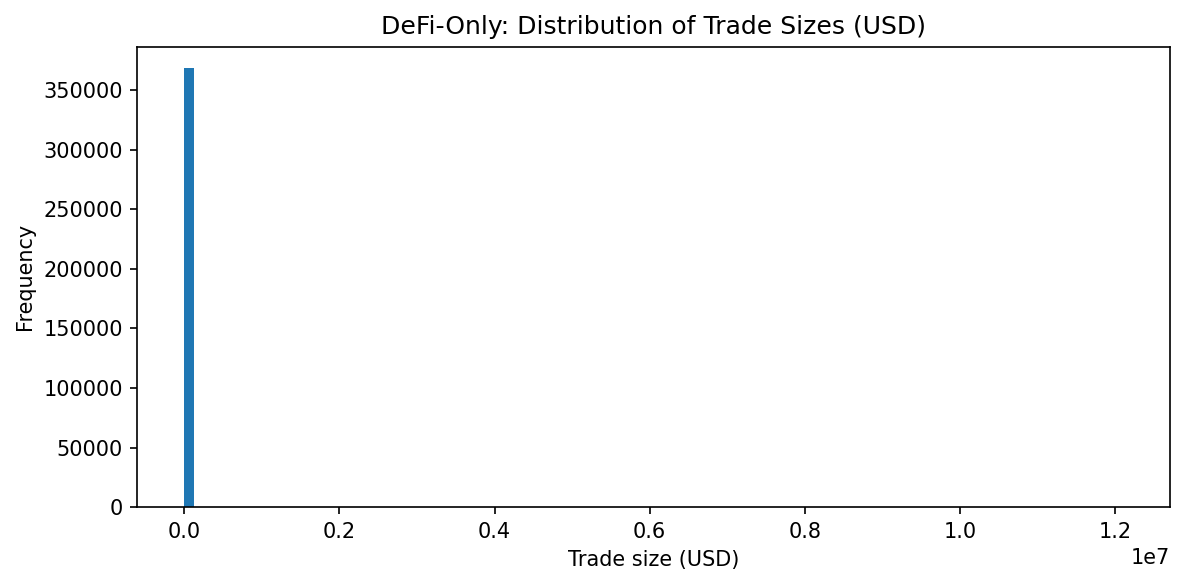

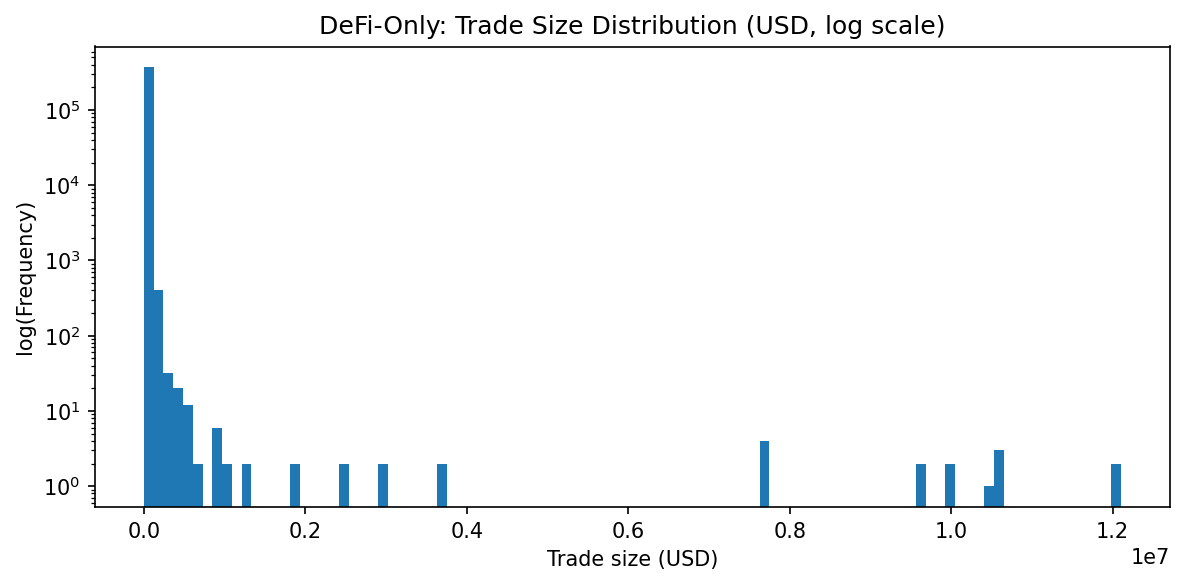

In [ ]:


plt.figure(figsize=(8,4), dpi=150)
plt.hist(df_defi["usd"], bins=100)
plt.title("DeFi-Only: Distribution of Trade Sizes (USD)")
plt.xlabel("Trade size (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Log-scale version to show tail better
plt.figure(figsize=(8,4), dpi=150)
plt.hist(df_defi["usd"], bins=100, log=True)
plt.title("DeFi-Only: Trade Size Distribution (USD, log scale)")
plt.xlabel("Trade size (USD)")
plt.ylabel("log(Frequency)")
plt.tight_layout()
plt.show()


In [54]:
import pandas as pd

entities = pd.unique(df[["from_entity", "to_entity"]].values.ravel())
entities = [e for e in entities if pd.notna(e)]

entities_df = pd.DataFrame({"entity": entities})


def classify_entity(e: str) -> str:
    if e in defi_list:
        return "DeFi"
    if e in cefi_list:
        return "Non-DeFi (CEX)"
    if e in wallet_list:
        return "Non-DeFi (Wallet)"
    if e in internal_list:
        return "Non-DeFi (Internal)"
    if e in infra_list:
        return "Non-DeFi (Infra)"
    e_lower = e.lower()
    if any(kw in e_lower for kw in ["swap","dex","amm","dao","protocol","finance"]):
        return "DeFi"
    if any(kw in e_lower for kw in ["exchange","binance","kraken","coinbase",
                                    "okx","bybit","kucoin","bitfinex","bitstamp"]):
        return "Non-DeFi (CEX)"
    if any(kw in e_lower for kw in ["mask","rainbow","zerion","wallet"]):
        return "Non-DeFi (Wallet)"
    if e.startswith("@"):
        return "Non-DeFi (Unknown individual)"
    if "wintermute" in e_lower:
        return "Non-DeFi (Internal)"
    return "Non-DeFi (Unknown)"

entities_df["classification"] = entities_df["entity"].apply(classify_entity)

class_map = dict(zip(entities_df["entity"], entities_df["classification"]))

df["from_class"] = df["from_entity"].map(class_map)
df["to_class"]   = df["to_entity"].map(class_map)


In [55]:
def coarse_class(c):
    if c == "DeFi":
        return "DeFi"
    elif isinstance(c, str) and c.startswith("Non-DeFi (CEX)"):
        return "CEX"
    else:
        return "Other"

df["to_coarse"] = df["to_class"].apply(coarse_class)



In [56]:
flow_stats = (
    df[df["from_entity"].isin(["Wintermute", "Rizzolver (Wintermute)"])]
    .groupby("to_coarse")["usd"]
    .sum()
)
print(flow_stats)


to_coarse
CEX      2.378999e+08
DeFi     4.143712e+08
Other    3.599749e+08
Name: usd, dtype: float64


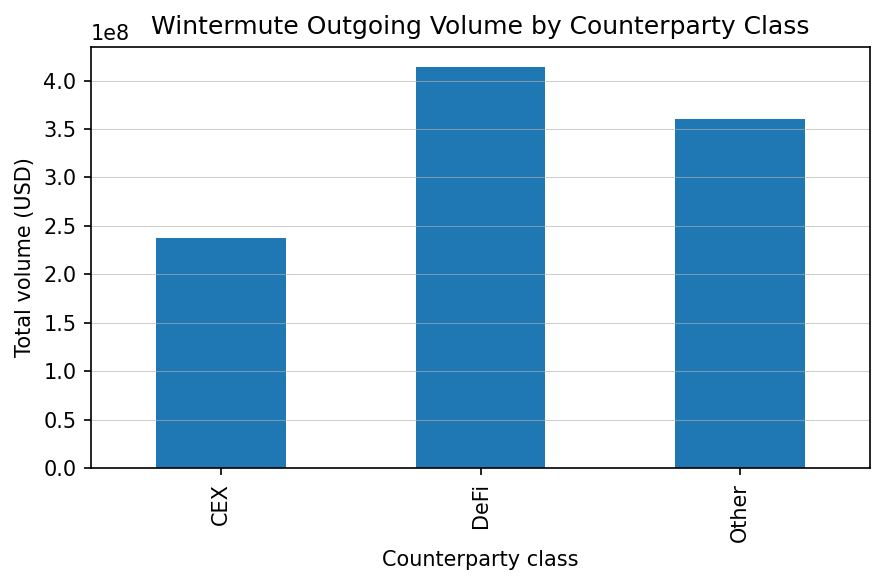

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4), dpi=150)
flow_stats.plot(kind="bar")
plt.title("Wintermute Outgoing Volume by Counterparty Class")
plt.xlabel("Counterparty class")
plt.ylabel("Total volume (USD)")
plt.grid(axis="y", linewidth=0.3)
plt.tight_layout()
plt.show()


In [58]:
from scipy.stats import kruskal

main_chains = df_defi["chain"].value_counts().head(4).index
sub = df_defi[df_defi["chain"].isin(main_chains)]

groups = [sub.loc[sub["chain"] == ch, "usd"].values for ch in main_chains]

stat, pval = kruskal(*groups)
print("Kruskal H =", stat, "p =", pval)


Kruskal H = 77039.3535223323 p = 0.0


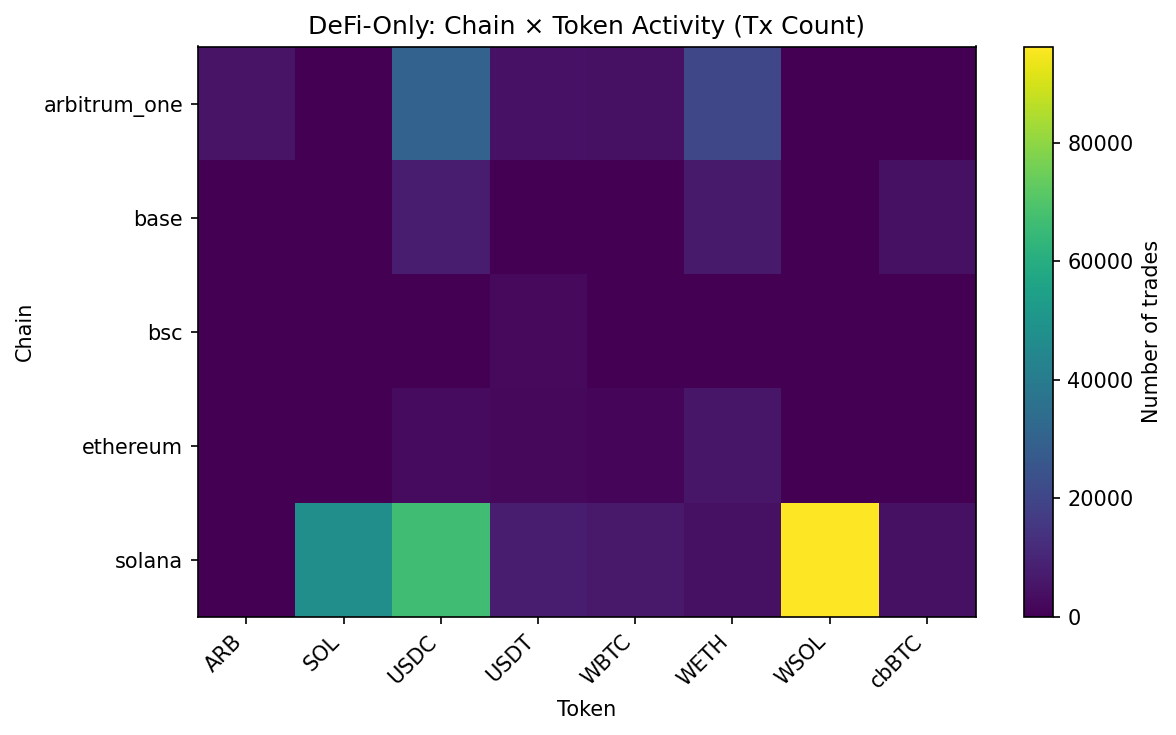

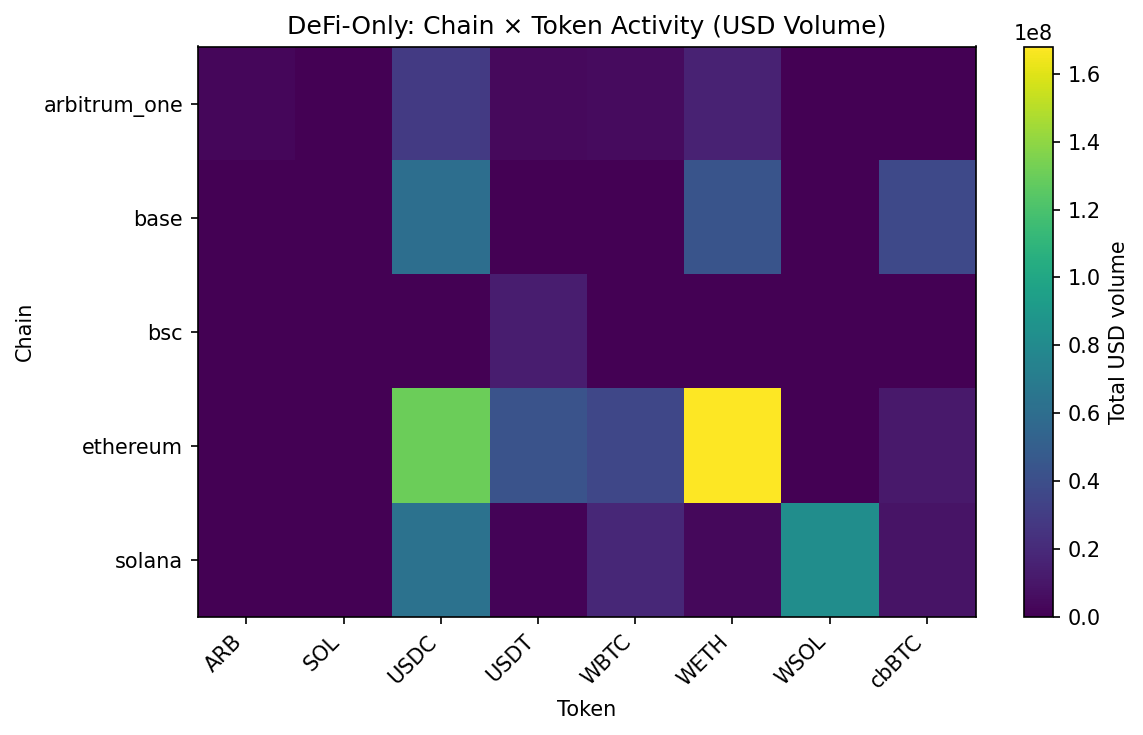

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


top_chains = df_defi["chain"].value_counts().head(5).index
top_tokens = df_defi["token"].value_counts().head(8).index

sub = df_defi[
    df_defi["chain"].isin(top_chains) &
    df_defi["token"].isin(top_tokens)
]


pivot_cnt = pd.crosstab(sub["chain"], sub["token"])

plt.figure(figsize=(8,5), dpi=150)
plt.imshow(pivot_cnt.values, aspect="auto") 
plt.title("DeFi-Only: Chain × Token Activity (Tx Count)")
plt.xlabel("Token")
plt.ylabel("Chain")

plt.xticks(
    ticks=np.arange(len(pivot_cnt.columns)),
    labels=pivot_cnt.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(pivot_cnt.index)),
    labels=pivot_cnt.index
)

plt.colorbar(label="Number of trades")
plt.tight_layout()
plt.show()


pivot_usd = sub.pivot_table(
    index="chain",
    columns="token",
    values="usd",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(8,5), dpi=150)
plt.imshow(pivot_usd.values, aspect="auto")
plt.title("DeFi-Only: Chain × Token Activity (USD Volume)")
plt.xlabel("Token")
plt.ylabel("Chain")

plt.xticks(
    ticks=np.arange(len(pivot_usd.columns)),
    labels=pivot_usd.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(pivot_usd.index)),
    labels=pivot_usd.index
)

plt.colorbar(label="Total USD volume")
plt.tight_layout()
plt.show()
